# Methoden en Technieken 2025-2026 -- Blok 3

## Datapunt Opdracht 3a

In deze opdracht worden de volgende leeruitkomsten getoetst, relevante termen zijn **dik** gedrukt:
- A2: Je stelt voor een AI-oplossing juridische, ethische, organisatorische, **functionele en technische requirements** op.
- B1: Je **verkent en prepareert een dataset voor het trainen en testen van een AI-model en kan de voor- en nadelen van het gebruik van een bestaande dataset onderbouwen**, rekening houdend met technische en ethische randvoorwaarden.
- B2: Je **stelt op basis van requirements en data een geschikte architectuur voor een AI-oplossing op en selecteert daarvoor passende AI-technieken gebruik makend van bijvoorbeeld** **machine learning**, deep learning, kennisrepresentatie, computer vision en **natural language processing**.
- B3: Je **ontwikkelt een nieuw** of voorgetraind **AI-model volgens een iteratief en systematisch proces**.
- C2: **Je evalueert en beoordeelt de kwaliteit van een AI-model aan de hand van kwaliteitscriteria die in het vakgebied erkend worden** zoals robustness, **performance**, scalability, explainability, **model complexity** en resource demand.


## De opdracht

Onderstaande code leest de data van verschillende *ratings* in. Deze dataset is de **MovieTweetings**-dataset (ook naar verwezen in Les 4 van blok 3) waar het MovieGEEKs-voorbeeld gebruik van maakt. In de data staan de waarderingen (van 0 t/m 10) van gebruikers voor verschillende films en bijbehorende *timestamp*. Zie ook https://github.com/sidooms/MovieTweetings/tree/master voor een uitleg van de dataset.

In [1]:
import pandas as pd
import surprise # Zie https://surpriselib.com/

In [2]:
ratings = pd.read_csv('https://raw.githubusercontent.com/sidooms/MovieTweetings/master/latest/ratings.dat',
                      delimiter='::', engine='python', header=None,
                      names = ['User_ID', 'Movie_ID', 'Rating', 'Rating_Timestamp'])

De bedoeling is om een aanbevelings-systeem te bouwen dat voor elke willekeurige gebruiker in het systeem drie films aanbeveelt. Probeer de aanbeveling zo persoonlijk mogelijk te maken.
* Kies een model en verantwoord deze keuze.
* Besluit hoe je het model beoordeelt (datasplitsing en maatstaf) en verantwoord deze keuze.
* Evalueer het model.
* Geef concrete suggesties om het model te verbeteren. Je hoeft deze verbeteringen niet uit te voeren.
* Bespreek voor- en nadelen van het model dat je hebt gemaakt.

In [3]:
# ratings # Heb dit uitgecomment omdat ik uit eerder gesprek met Robert heb vernomen dat dit al data leakage zou kunnen zijn

---

# 1. EDA
Als ik zo naar de data kijk, die perongelijk naar ons geleakt is door de opdrachtmaker, vallen me een paar dingen op. (De dingen die me opvallen had ik ook kunnen zien door enkel naar de trainset te kijken dus dit veranderd niks)

## 1.1 Timestamps
Ik zie dat er timestamps staan in de dataset. Met de timestamps kunnnen we voornamelijk 2 dingen. Je kunt kijken op welk tijdstip welke film wordt gekeken. Zo kun je misschien linken dat horror films vaak snachts worden bekeken en blije films overdag. Dan zou je in het reccomendatie systeem kunnen inbouwen dat hoe laat je de code runt, invloed kan hebben op de recomendaties die gegeven worden. Dit is een erg gaaf concept, maar toch niet zo praktisch als het klinkt. De dataset bevat reviews en reviews kunnen op elk moment van de dag gegeven worden. Zo kun je een horror film kijken snachts en morgen middag er een review over schrijven. Daarom laat ik dit concept volledig achterwegen

Ook kunnen we timestamps gebruiken om de dataset chronologisch te ordenen. Een voordel hiervan zou zijn dat we een beter beeld krijgen bij welke films een user heeft gekeken om eventueel interesses te krijgen in de films die de user erna heeft gekeken. Ook zou je kunnen denken dat we nuttige "user feedback" simuleren. Als in: in de train set kijkt een persoon films, op basis van de films in de trainset doe ik recomendaties, vervolgens krijgen we terug welke films een user dan gekeken heeft en kunnen we zo proberen te beoordelen hoe goed mijn recomendaties waren. Het probleem is echter dat de recomendaties die ik ga maken geen invloed hebben op de gesimuleerde "user feedback". Het chronolisch ordenen is op dit gebied dus niet perse een voordeel maar ook niet perse een nadeel, aangezien mijn recomendaties gebasseerd op de trainset los staat van de "feedback" in de val of test set. Idealiter, geef ik recomendaties in de praktijk en ga ik nadat ik mijn recomendaties gedaan heb bijhouden hoe effectief deze zijn. Zo is de user feedback direct gelinkt aan mijn recomendaties. Maar dat is in dit geval niet omdat we te maken hebben met een statische dataset, dus probeer ik er maar het best van te maken. Wat ik wil zeggen is, hoe "goed" mijn recomendaties ook zijn. Bij het evalueren krijgen we geen eerlijke user feedback terug omdat deze users mijn recomendaties nooit gezien hebben. Dit maakt het evalueren van mijn recomendaties dus ingewikkeld.

Na lang te filosoferen over wat te doen met de timestamps ben ik tot de conclusie gekomen om de gehele dataset chronologisch te ordenen voor het splitsen van de data met als hoofdreden: omdat we zo toch een kloppende volgorder creëren van films die de users gezien hebben en zo dus kloppendere recomendations kunnen genereren (zie codeblock 2a). Ik ben ervan op de hoogte dat we dan de val en test set licht manipuleren maar dat moet haast wel in dit fictief scenario.

## 1.2 Cold Start 
Ik zie in de dataset dat er users zijn die maar 1 film hebben beoordeeld [*2.3 Data Verkenning (#2.3.2 Aantal Reviews per Gebruikers (Train Set))*](#23-data-verkenning). Falk zegt in zijn boek *"Many scientific papers say that recommendations can’t be calculated before a user has rated at least 20 to 50 items.*. Ik wil de science volgen en deze range van 20-50 toepassen. Aangezien we niet kunnen weten hoeveel beoordelingen een user in de val of test set heeft staan. Ga ik een minimum stellen dat een user minimaal 20 films beoordeeld moet hebben in de train set. Zo kunnen we proberen voor deze users zo logisch mogelijk recomendations te genereren. Maar wat doen we met de rest van de users? In de opdracht staat duidelijk: **De bedoeling is om een aanbevelings-systeem te bouwen dat voor elke willekeurige gebruiker in het systeem drie films aanbeveelt. Probeer de aanbeveling zo persoonlijk mogelijk te maken.**. Het is dus van belang recommendations te genereren voor **elke** willekeurige user, ongeacht hoeveel films die al beoordeeld heeft. Ander belangrijk punt is dat we ze zo **persoonlijk mogelijk** moeten maken. Om dit gehele probleem op te lossen ga ik dus concreet: Als de user 20 films of meer heeft beoordeeld in de trainset ga ik gepersonaliseerd films aanraden. Als de user minder dan 20 films heeft beoordeeld in de trainset ga ik de 3 meest populaire films aanraden. (Ik interpreteer populair als vaakst beoordeeld. Meest populair kan ook betekenen hoogste beoordeling, maar een film met 1 beoordeling van een 10.0 zou dan een film van 1000 beoordelingen met een 9.5 outperformen en dat wil ik niet).

## 1.3 Rating Interval
Door het inzien dan de eerste 5 en laatste 5 rows kreeg ik het vermoeden dat de ratings zitten tussen de 1 en de 10. Vervolgens heb ik mijn trainset verkend in [*2.3 Data Verkenning (#2.3.1 Algemene Dataset Statistieken)*](#23-data-verkenning) en heb ik gezien dat de minimale rating een 0 is en de maximale rating een 10 is.

## 1.4 Data Volume
Het is me opgevallen dat we erg veel data hebben.

# 2. Data Preperation

## 2.1 Chronologisch Ordenen
Als eerder verantwoord in [*1.1. Timestamps*](#11-timestamps) ga ik de gehele dataset chronologisch ordenen.

In [4]:
# 2.1.1 Chronologische Ordenen

# imports
from sklearn.model_selection import train_test_split

# chronologisch sorteren op timestamp
ratings_chronological = ratings.sort_values(by='Rating_Timestamp')

## 2.2 Datasplit
Vervolgens ga ik de dataset splitsen. Falk zegt: *"It’s a good idea to split the data around 80–20, but that isn’t a rule. It’s important to have as much data as possible to train the algorithm,"* ook zegt hij eerder dat het goed is om een train test en validatieset te gebruiken. Daarom ga ik de sets spltisen op de volgende manier: train (80%) test (10%) en validatie set (10%).

In [5]:
#2.2.1 Dataset Splitsen

# split 80/10/10
train_data, temp_data = train_test_split(ratings_chronological, test_size=0.2, shuffle=False)
val_data, test_data = train_test_split(temp_data, test_size=0.5, shuffle=False)

## 2.3 Data Verkenning
Vekenning van de train split

In [6]:
#2.3.1 Algemene Dataset Statistieken

train_data.describe()

,User_ID,Movie_ID,Rating,Rating_Timestamp
count,737118.000000,7.371180e+05,737118.000000,7.371180e+05
mean,36120.366011,1.826545e+06,7.299584,1.436421e+09
std,20832.626031,1.454675e+06,1.857117,5.111769e+07
min,1.000000,8.000000e+00,0.000000,1.362062e+09
25%,18397.000000,4.892700e+05,6.000000,1.390113e+09
50%,35936.000000,1.648190e+06,7.000000,1.428107e+09
75%,53849.000000,2.406566e+06,9.000000,1.480101e+09
max,71707.000000,9.063106e+06,10.000000,1.540250e+09


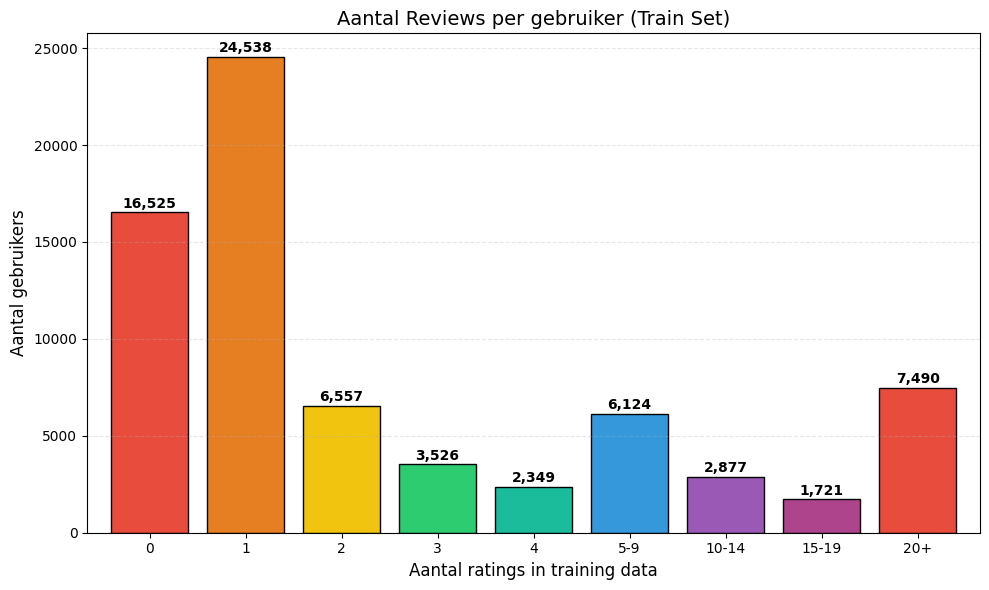

In [7]:
#2.3.2 Aantal Reviews per Gebruikers (Train Set)
import pandas as pd
import matplotlib.pyplot as plt

# 1. Haal alle unieke gebruikers op uit de volledige dataset
alle_users = ratings['User_ID'].unique()

# 2. Tel ratings per gebruiker in de train_data
# We gebruiken reindex om gebruikers met 0 ratings in de train_set mee te tellen
user_counts = train_data['User_ID'].value_counts().reindex(alle_users, fill_value=0)

# 3. Definieer de grenzen (bins) en de namen (labels)
# De bins werken als volgt: (-1, 0], (0, 5], (5, 10], (10, 15], (15, 19], (19, inf]
bins = [-1, 0, 1, 2, 3, 4, 9, 14, 19, float('inf')]
labels = ['0', '1', '2', '3', '4', '5-9', '10-14', '15-19', '20+']

# 4. Deel de gebruikers in
user_segments = pd.cut(user_counts, bins=bins, labels=labels)
segment_counts = user_segments.value_counts().sort_index()

# 5. Plotten
plt.figure(figsize=(10, 6))
colors = [
    '#e74c3c', # Rood (0)
    '#e67e22', # Oranje (1)
    '#f1c40f', # Geel (2)
    '#2ecc71', # Groen (3)
    '#1abc9c', # Turkoois/Teal (4-9)
    '#3498db', # Blauw (10-14)
    '#9b59b6', # Paars (15-19)
    "#ad448c"  # Donker Violet (20+)
]
bars = segment_counts.plot(kind='bar', color=colors, edgecolor='black', width=0.8)

plt.title('Aantal Reviews per gebruiker (Train Set)', fontsize=14)
plt.xlabel('Aantal ratings in training data', fontsize=12)
plt.ylabel('Aantal gebruikers', fontsize=12)
plt.xticks(rotation=0)

# Voeg de exacte aantallen toe boven de balken voor duidelijke rapportage
for i, v in enumerate(segment_counts):
    plt.text(i, v + (max(segment_counts)*0.01), f'{v:,}', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Het valt me op dat er erg veel users zijn die in de trainset 0 films hebben gekeken. Als er users zijn in de trainset met 0 reviews, zullen er vast ook users zijn in de val en testset met 0 reviews. Mochten we precision, recall of F1 gebruiken betekent dat, dat er veel users gaan zijn waarbij het hoogst mogelijk score dat je kunt halen 0% gaat zijn. Bij users die maar 1 film hebben beoordeeld is de hoogst mogelijk precision 33% en de hoogst mogelijke recall 100% (als die ene review in de val, of test set valt). Ten slotte hebben we het chronologisch gesorteerd dus zijn kansen dan nog wel even eerlijk? Kunnen we ervan uitgaan dat 16.525 users ongeveer 80% is van alle users die 0 films hebben gekeken? En mogen we ervan dan uitgaan dat er 10% in de valset en 10% in de testset zit met 0 reviews?

Nogmaals, na heel lang te filosoferen over deze vragen. Ben ik met het volgende idee gekomen:

## 2.4 Chronologisch Ordenen en per user
We gaan eerst van elke user de eerst rating pakken in tijd, dan de tweede per user dan de derde etcetera. Hierdoor zorgen we ervoor dat er een stuk minder ratings met als waarde 1, 2 of 3 terecht komen in de validatie en testset. Dit is goed want als iemand maar 1 film heeft gezien, waarom zouden we hem dan in de testset zetten? we hebben niks om op te trainen. We kunnen net zo goed die ene user dan in de trainset houden want dan weten we gegarandeerd dat die ene user een precision van 0 gaat opleveren. Zo kunnen we uitrekenen hoeveel users gegarandeerd een precision van 0 geven en zo een nieuwe eigen metriek opstellen die beter werkt dan precision. Hier later meer over

In [8]:
#2.4.1 Chronologische per User

# Zorg dat de ratings PER GEBRUIKER eerst chronologisch staan
ratings = ratings.sort_values(by=['User_ID', 'Rating_Timestamp'])

# Maak een nieuwe kolom 'nth_rating' (de 1e, 2e, 3e rating van die specifieke user)
ratings['nth_rating'] = ratings.groupby('User_ID').cumcount() + 1

# Sorteer nu de hele dataset: eerst alle 1e ratings, dan alle 2e, etc.
ratings_interleaved = ratings.sort_values(by=['nth_rating', 'Rating_Timestamp'])

In [9]:
#2.4.2 Dataset Splitsen

# split 80/10/10
train_data, temp_data = train_test_split(ratings_interleaved, test_size=0.2, shuffle=False)
val_data, test_data = train_test_split(temp_data, test_size=0.5, shuffle=False)

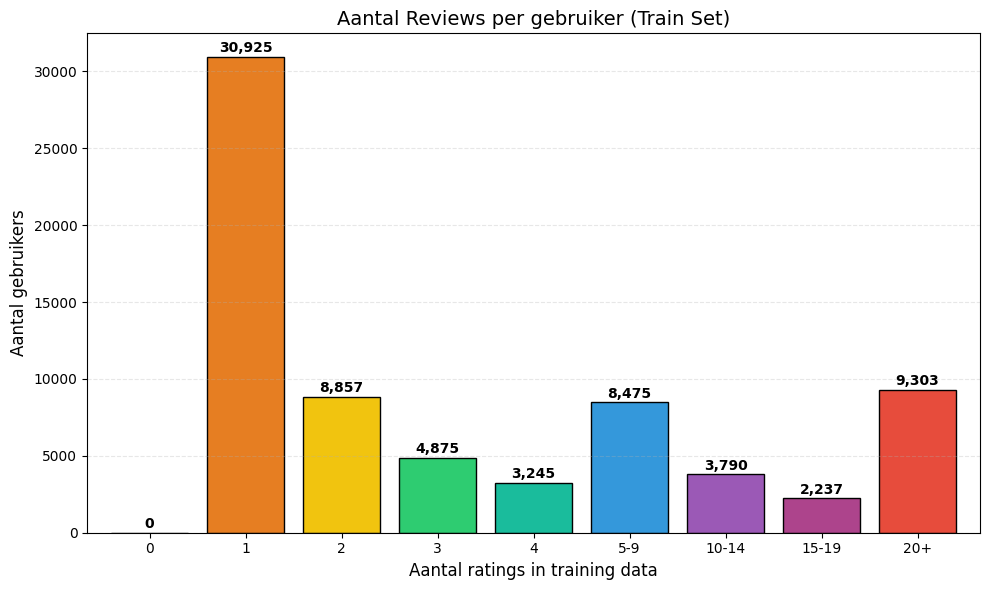

In [10]:
#2.4.3 Aantal Reviews per Gebruikers (Train Set)
import pandas as pd
import matplotlib.pyplot as plt

# 1. Haal alle unieke gebruikers op uit de volledige dataset
alle_users = ratings['User_ID'].unique()

# 2. Tel ratings per gebruiker in de train_data
# We gebruiken reindex om gebruikers met 0 ratings in de train_set mee te tellen
user_counts = train_data['User_ID'].value_counts().reindex(alle_users, fill_value=0)

# 3. Definieer de grenzen (bins) en de namen (labels)
# De bins werken als volgt: (-1, 0], (0, 5], (5, 10], (10, 15], (15, 19], (19, inf]
bins = [-1, 0, 1, 2, 3, 4, 9, 14, 19, float('inf')]
labels = ['0', '1', '2', '3', '4', '5-9', '10-14', '15-19', '20+']

# 4. Deel de gebruikers in
user_segments = pd.cut(user_counts, bins=bins, labels=labels)
segment_counts = user_segments.value_counts().sort_index()

# 5. Plotten
plt.figure(figsize=(10, 6))
colors = [
    '#e74c3c', # Rood (0)
    '#e67e22', # Oranje (1)
    '#f1c40f', # Geel (2)
    '#2ecc71', # Groen (3)
    '#1abc9c', # Turkoois/Teal (4-9)
    '#3498db', # Blauw (10-14)
    '#9b59b6', # Paars (15-19)
    "#ad448c"  # Donker Violet (20+)
]
bars = segment_counts.plot(kind='bar', color=colors, edgecolor='black', width=0.8)

plt.title('Aantal Reviews per gebruiker (Train Set)', fontsize=14)
plt.xlabel('Aantal ratings in training data', fontsize=12)
plt.ylabel('Aantal gebruikers', fontsize=12)
plt.xticks(rotation=0)

# Voeg de exacte aantallen toe boven de balken voor duidelijke rapportage
for i, v in enumerate(segment_counts):
    plt.text(i, v + (max(segment_counts)*0.01), f'{v:,}', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

*We hebben nogmaals op een bepaalde manier data leakage gecreëerd want ik weet dat alle users in de val and test set nu meer dan 20 films hebben gezien. Maar ik baseer hier verder geen keuzes op*

Ik heb met opzet data leakage gecreeerd. ik vind het niet erg om in dit fictief scenario op deze manier data leakage te creëeren. In tegendeel, dit heeft juist zijn voordelen. Ik weet nu dat alle users die 1 film hebben beoordeeld in de train set zitten. Hetzelfde geld voor alle users die maar 2 of 3 of 19 films hebben gezien. Dit is een voordeel, want iedereen die maar 1, 2 of 3 films heeft gezien rumineert het idee van precision. Je kunt geen 100% precision halen op iemand die maar 1 of 2 films heeft gezien. En de kans dat je een precision van 100% behaalt op iemand die maar 3, 4 of 5 films heeft gezien is ook miniscuul omdat deze ratings dan weer verdeeld worden over verschillende sets.

> Maar waarom haal ik niet dan gewoon de "cold users" uit de dataset? Goede vraag. In de opdracht staat dat we voor elk willekeurige user 3 films moeten aanbevelen. Ook cold users. Ook al gaat dit de precision ver omlaag halen, is het toch waardevol om uit te rekenen wat de "modified precision" gaat zijn. Als we de cold users eruit mochten halen, dan had ik niet data leakage hoeven te creeeren, want dan weten we al zeker dat alle users genoeg films hebben gezien en konden we eventueel met stratification zeker weten dat de films mooi verdeeld zijn maar nog wel gesorteerd op tijd. Stel nou dat je toch cold users mocht weghalen had ik het zo gedaan.

## 2.5 Modified Precision
**Nu ga ik de validatieset inzien.** De reden dat ik dit doe is om een betere evaluatiemetriek op te stellen. we zien dat 70.291 mensen geen reviews hebben in de validatie set (zie #2.5.1). We zien ook dat 7 mensen maar 1 review hebben in de val set, 12 mensen 2 reviews en 1397 hebben er 3 of meer. Nu we dit weten kunnen we uitrekenen wat het maximale precision is dat we kunnen behalen in deze opdracht. 

> 70.291 + 7 + 12 + 1397 = 71.707 totale users in de gehele dataset.

| Groep Gebruikers | Aantal  | Max. hits bij k=3 | Max. Precision per gebruiker |
|------------------|---------|-------------------|-----------------------------|
| 0 reviews        | 70.291  | 0                 | 0%                          |
| 1 review         | 7       | 1                 | 33.33%                      |
| 2 reviews        | 12      | 2                 | 66.67%                      |
| 3+ reviews       | 1.397   | 3                 | 100%                        |

$$\text{Max Precision} = \frac{(70.291 \times 0) + (7 \times 1) + (12 \times 2) + (1.397 \times 3)}{71.707 \times 3} = \frac{4.222}{215.121} \approx 0.019627$$


Dat komt ongeveer uit op `1.9627...%`. Dus het beste van het beste wat we kunnen bereiken is ongeveer `1.96%`. dit wetende kunnen we uitrekenen hoe goed ons model het echt doet door een nieuwe evaluatiemetriek op te stellen die ik noem "Modified Precision". 

$$\text{Modified Precision}_{\text{VAL}} = \frac{\text{Behaalde Score}}{\text{Maximale Score (0.019627...)}} \times 100\%$$

> Belangrijk: Deze modified precision werkt alleen op deze valset, omdat we de getallen van deze valset gebruiken. Mocht je testen op de testset, moet je voordat je gaat testen eerst de nieuwe modified precision uitrekenen. Het uitrekenen van de modified precision is niet erg als je gelijk daarna gaat testen want dan baseer je geen keuzes op de data leakage.

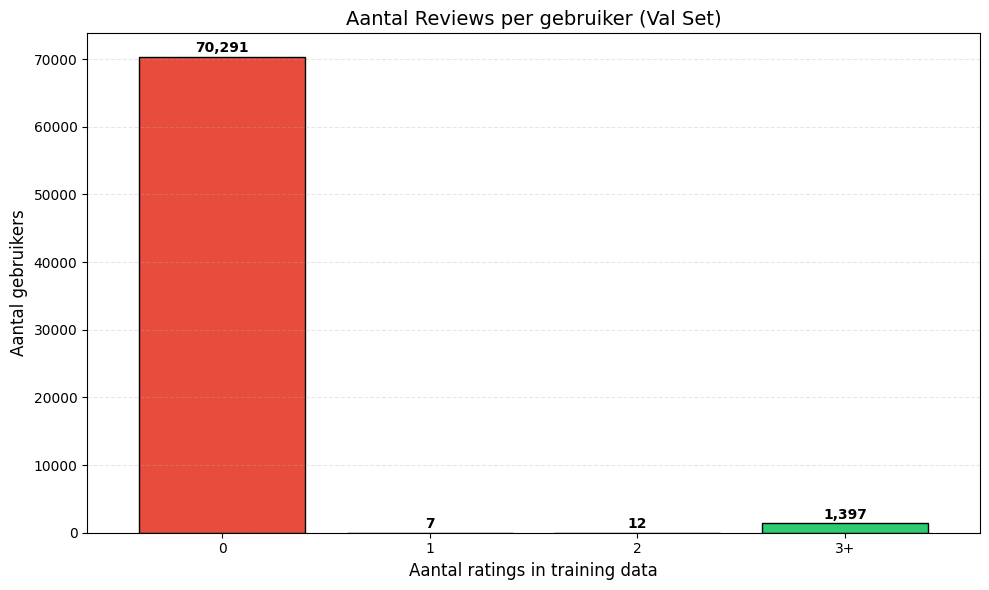

In [11]:
#2.5.1 Aantal Reviews per Gebruikers (Val Set)
import pandas as pd
import matplotlib.pyplot as plt

# 1. Haal alle unieke gebruikers op uit de volledige dataset
alle_users = ratings['User_ID'].unique()

# 2. Tel ratings per gebruiker in de train_data
# We gebruiken reindex om gebruikers met 0 ratings in de train_set mee te tellen
user_counts = val_data['User_ID'].value_counts().reindex(alle_users, fill_value=0)

# 3. Definieer de grenzen (bins) en de namen (labels)
# De bins werken als volgt: (-1, 0], (0, 5], (5, 10], (10, 15], (15, 19], (19, inf]
bins = [-1, 0, 1, 2, float('inf')]
labels = ['0', '1', '2', '3+']

# 4. Deel de gebruikers in
user_segments = pd.cut(user_counts, bins=bins, labels=labels)
segment_counts = user_segments.value_counts().sort_index()

# 5. Plotten
plt.figure(figsize=(10, 6))
colors = [
    '#e74c3c', # Rood (0)
    '#e67e22', # Oranje (1)
    '#f1c40f', # Geel (2)
    '#2ecc71', # Groen (3)
    '#1abc9c', # Turkoois/Teal (4-9)
    '#3498db', # Blauw (10-14)
    '#9b59b6', # Paars (15-19)
    "#ad448c"  # Donker Violet (20+)
]
bars = segment_counts.plot(kind='bar', color=colors, edgecolor='black', width=0.8)

plt.title('Aantal Reviews per gebruiker (Val Set)', fontsize=14)
plt.xlabel('Aantal ratings in training data', fontsize=12)
plt.ylabel('Aantal gebruikers', fontsize=12)
plt.xticks(rotation=0)

# Voeg de exacte aantallen toe boven de balken voor duidelijke rapportage
for i, v in enumerate(segment_counts):
    plt.text(i, v + (max(segment_counts)*0.01), f'{v:,}', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Maatstaf
Hoe ga ik mijn model en het baseline model beoordelen? 

## 3.1 Baseline Model
Falk zegt: *"Before you evaluate your new recommender, you should evaluate it on a simple recommender that, for example, always recommends the most popular items and see what numbers come out."* Michelangelo gaf in de les ook aan dat het een goed idee is om een baseline te gebruiken en het recommenden van populaire items daar een goed idee voor is. Daarom ga ik voor mijn baseline populair films aanraden. *Maar wat is populair?* Het gebruik van de best beoordeelde films kan zorgen voor problemen, aangezien een film die 2 keer beoordeeld is met een gemmiddelde score van 10.0 hoger kan staan dan een film die 1000 keer is beoordeeld met een gemmiddelde score van 9.9. Om dit op te lossen ga ik populariteit definiëren als vaakst beoordeeld.

## 3.2 Evaluatie Metriek
Ten eerste is het best awkward om een offline experiment uit te voeren voor een recommender system aangezien je in feiten goeie recomendations zou kunnen maken, maar je krijgt nooit direct feedback terug van de user op de recommendations die je maakt. Falk noemt meerdere evaluatie metrics zoals: RMSE, MAE, DCG, NDCG, Precision, Recall en F1-Score. Ik ben van mening dat metrics als RMSE, MAE, DCG, NDCG goed zouden kunnen werken als je een dataset hebt waarin elke user gigantisch veel films heeft gekeken. Het probleem met de huidige dataset is dat er heel veel mensen maar een paar films hebben gezien. Mocht je ratings gaan predicten zul je erg vaak krijgen dat je de predicted rating moet gaan vergelijken met een niet bestaand getal. Dit zou je dan weer kunnen oplossen door voor iedereen bij elke film een 5 in te vullen aangezien 5 niet perse leuk en niet perse niet leuk is maar het lijkt me fout om voor iedereen zo maar in te vullen wat hen voorkeuren zijn dus ga ik deze metrieken absoluut niet gebruiken met als reden dat we teveel aannames moeten maken.

Het lijkt mij het meest logisch om een rating te interpreteren als "heeft film gezien" en geen rating als "heeft film niet gezien". Als een user een film gezien heeft was deze film op dat moment in tijd dusdanig interessant genoeg voor de user om de film te kijken en dus op dat moment in tijd een goede recommendation. 

Door ratings te interpreteren als "heeft gezien = vond interessant" en "niet gezien = vond niet interessant" kunnen we daadwerkelijk meten hoe goed het model presteert door te proberen films aan te raden die de user ook daadwerkelijk gezien heeft. Dit sluit mooi aan op de metrieken precision, recall en f1-score aangezien het nu meer een classificatie probleem wordt. Aangezien de opdracht is om enkel 3 films aan te bevelen is het onlogisch om te kijken naar recall, aangezien je 3 goede films kunt aanbevelen, maar als de gebruiker in totaal 30 films heeft beoordeeld dan heb je dus maar een recall van 0.10. omdat recall afhankelijk is van de user in dit secnario vind ik het onlogisch en valt het af in mijn evaluatiemetriek keuze. Omdat recall afvalt, valt F1-score dus ook af, dus is de meest logische metriek in mijn opvatting van deze opdracht precision.

Ik zeg dat recall afhankelijk is van de user. En dit klopt ook. Maar precision is toch ook afhankelijk van de user? als iemand 0, 1 of 2 films in de validatie of test set heeft staan en je **moet** 3 films aanraden kun je voor die user al geen 100% precision halen. Dit probleem heb ik volledig opgelost door in de validatieset te kijken en mijn eigen metriek op te stellen. Deze metriek noemde ik al eerder "Modified Precision" zie [*2.5 Modified Precision*](#25-modified-precision). 

Het enige gat in mijn denkwijze bij het interpreteren van "heeft film gezien = vond film interessant" en "heeft film niet gezien = vond film niet interessant" is: Iemand die een film nog niet gezien heeft, had deze film wel interessant kunnen vinden. Misschien heeft die ene user deze fantastische film nog niet aangeraden gekregen. Ik ben op de hoogte van dit gat, maar ga het negeren omdat je altijd wel ergens tegen aal gaat lopen. 

Na mijn mening kun je in dit scenario, een offline experiment recommendation systeem bouwen met statische data, niet een model bouwen dat 100% overal aan voldoet en overal rekening mee houdt. Op mijn manier bijna dus wel.

## 3.3 Crossvalidatie
Cross-validatie is geen goed idee omdat we chronologische data gebruiken. We willen juist op de historische data trainen en de minst oude data predicten. Cross-validatie gooit juist de data door elkaar en is daarom niet handig 

Ik heb overwogen om toch cross-validatie te gebruiken en het variabel tijd volledig weg te laten. Zoals ik eerder heb benoemd zijn de nieuwste ratingen tòch geen resultaat van **mijn recommendations** dus wat maakt het dan uit als we de ratingen dan door elkaar gooien? Maar het feit dat de chronologische historische data wel correct is, heeft mij overtuigd om toch wel de data chronologisch te ordenen. Zo kunnen we de historische data gebruiken om recommendations te maken.

## 3.4 Stratification
Onlogisch in dit scenario omdat ik zelf al best specifiek de data heb gesplitst. Stratification zou dit alleen maar dwars zitten en door elkaar gooien.

# 4. Voor- en Nadelen van de Dataset
Oke. Er is erg veel gezegd over datasets voordelen en nadelen dus probeer ik hier alles even concreet in het kort samentevatten (sorry).

## 4.1 Voordelen
- v1. Er is gigantisch veel data. 921.000+ rows
- v2. Er zijn timestamps waardoor je een idee kunt krijgen welke films iemand gekeken heeft, op welke volgorde èn wanneer. De timestamps kun je ook op andere manieren toepassen wat ik niet doe. Voor gedetailleerde uitleg zie *[1.1 Timestamps](#11-timestamps)*
- v3. veel unieke users ongeveer zo'n 71 duizend. Dit is een voordeel, want stel dat we een dataset hebben met 11 users. Er zijn 10 users die allemaal horror films kijken en er is één user die mainstream films kijkt. dan is het moeilijk om voor die mainstream user films te recomenden omdat ze waarschijnlijk weinig overlap hebben met gekeken films (ik gebruik Collaborative Filtering).

## 4.2 Nadelen
- n1. Statische dataset. het maakt niet uit hoe goed je recomendations zijn. De feedback is statisch en is niet een directe response op jouw recomendations
- n2. je moet 3 films recomenden maar er zijn erg veel users die niet een 3 films gezien hebben. Dit maakt precision moeilijk en collaborative filtering moeilijk, content based moeilijk. een van de weinige dingen die hier benefit uit haalt is recall. Stel je gokt die ene film goed heb je gelijk 100% recall. Maar als je 3 films van de 2500 goed gokt ben je ver van huis. Dit los ik op met *strategisch data leakage* waardoor ik de modified precision kan uitrekenen.

# 5. Baseline Model Implementatie
Voor mijn baseline model ga ik als eerder benoemd de 3 meest bekeken films aanraden aan iedereen

In [12]:
#5.1 Bereken hoevaak elke film is bekeken
from sklearn.model_selection import train_test_split
import pandas as pd

movie_stats = train_data.groupby('Movie_ID')['Rating'].agg(['count'])
movie_stats_named = movie_stats.reset_index()
movie_stats_named.sort_values(by='count', ascending=False)

,Movie_ID,count
15557,1454468,3008
12791,816692,2769
13405,993846,2728
29501,8579674,2724
12525,770828,2638
...,...,...
14282,1190072,1
14289,1190867,1
14290,1190894,1
14291,1190910,1


Pak de top 50 want stel we raden films 1, 2 en 3 aan. Maar x user heeft deze films al gezien in de trainset, dan gaan we sowieso een precision van 0 halen. Daarom zeg ik, *Als een user een film aangeraden krijgt die die al gezien heeft raad dan de volgende aan in plaats daarvan*.

In [13]:
#5.2 Get the top 50 Movie_IDs based on rating count
top_50_popular_ids = movie_stats.sort_values(by='count', ascending=False).head(50).index.tolist()

print(f"Top 50 Popular Movie IDs: {top_50_popular_ids}")

Top 50 Popular Movie IDs: [1454468, 816692, 993846, 8579674, 770828, 7286456, 816711, 1300854, 1670345, 2267998, 1535109, 1392214, 1343092, 1408101, 2084970, 1800241, 2024544, 1483013, 1951264, 1663202, 1798709, 1392190, 6751668, 2582802, 1979320, 2278388, 1853728, 1877832, 1843866, 1170358, 1663662, 790636, 1457767, 1431045, 1535108, 1981115, 2015381, 1045658, 2119532, 5013056, 3783958, 1631867, 2975590, 7131622, 2543164, 1430132, 2562232, 831387, 2713180, 2872718]


validatieset checken welke films iemand allemaal al heeft gezien voor zometeen het evalueren van het basleline model

In [14]:
#5.3 Group val data to see what each user actually watched
user_val_movies = val_data.groupby('User_ID')['Movie_ID'].apply(set).reset_index()
user_val_movies.columns = ['User_ID', 'actual_movies']
user_val_movies

,User_ID,actual_movies
0,66,"{1409024, 2172934, 452623, 2660888, 1229340, 4..."
1,69,"{8236336, 2527338, 2231461, 3774114}"
2,111,"{1431045, 3170832, 3544082, 95765, 3203606, 78..."
3,116,"{8946378, 8579674, 6062774}"
4,123,"{1431045, 2322441, 1618442, 1186830, 359950, 1..."
...,...,...
1411,71594,"{6018306, 57091, 5580036, 101640, 1366409, 683..."
1412,71604,"{5324800, 9412098, 3774466, 5804038, 1618442, ..."
1413,71616,"{1959490, 63522, 475290, 55031, 2334873, 18215..."
1414,71686,"{2446980, 381061, 448134, 1431045, 1712261, 41..."


baseline model runnen

In [15]:
#5.4 Baseline Precision op Valset
# 1. Maak een lijst van ALLE unieke User_IDs
alle_users = ratings['User_ID'].unique()

# 2. Maak een dictionary van wat men al heeft gezien (Train)
user_train_seen = train_data.groupby('User_ID')['Movie_ID'].apply(set).to_dict()

# 3. Maak een dictionary van wat men daadwerkelijk heeft gekeken (Val)
# Belangrijk: we gebruiken een dict voor snelle lookup
user_val_actual = val_data.groupby('User_ID')['Movie_ID'].apply(set).to_dict()

# 4. De Top 50 lijst (basis voor populariteit)
top_50_popular_ids = movie_stats.sort_values(by='count', ascending=False).head(50).index.tolist()

# 5. Functie voor aanbevelingen (filter seen items)
def get_top_3_unseen(user_id):
    seen = user_train_seen.get(user_id, set())
    recommended = [m for m in top_50_popular_ids if m not in seen]
    return recommended[:3]

# 6. Bereken de totale precision
total_hits = 0

for user_id in alle_users:
    # Doe de aanbeveling
    predicted = get_top_3_unseen(user_id)
    
    # Kijk wat de user echt heeft gekeken in de validatieset
    actual = user_val_actual.get(user_id, set())
    
    # Tel de hits (overlap tussen predicted en actual)
    hits = len(set(predicted) & actual)
    total_hits += (hits / 3) # We delen door 3 omdat k=3

# 7. Bereken het gemiddelde over de GEHELE populatie
avg_precision_total = total_hits / len(alle_users)

print(f"Totale Populatie Precision@3: {avg_precision_total:.6f}")

Totale Populatie Precision@3: 0.001683


Met het baseline model halen we dus een precision van 0.001683 dit geeft ons een modified precision van ongeveer 8.58%

$$\text{Modified Precision} = \frac{0.001683}{\text{0.019627}} \times 100\% \approx 8,58\%$$

# 6. Requirements
Nu we alle theorie en het baseline model achter de rug hebben is het mogelijk om de requirements op te stellen van de opdracht
- R1. **Modified Precision als Evaluatiemetriek** - Ik heb veel metrieken overwogen en het meest logische van alles is precision. Toch is precision niet helemaal veilloos. Daarom heb ik precision een beetje veranderd om het zo eerlijk mogelijk te houden en daarom gebruik ik mijn eigen "Modified Precision". Hier meer info over in [*2.4 Chronologisch ordenen en per user*](#24-chronologisch-ordenen-en-per-user), [*2.5 Modified Precision*](#25-modified-precision) en [*3.2 Evaluatie Metriek*](#32-evaluatie-metriek)
- R2. **Mijn model moet een hogere Modified Precision halen dan 8.58%** - Het baseline model behaalt een modified precision van 8.58%. Zie Codeblock: `#5.4 Baseline Precision op Valset`.
- R3. **Collaborative Filtering als algoritme** - Er is geen movie meta-data in de gegeven dataset waardoor andere approaches (Content-based / Hybrid Approach) niet mogelijk zijn.
- R4. **3 films aanraden per user** - In de opdracht staat dat voor elk willekeurige user 3 films moet aangeraden worden.
- R5. **Minimaal 1 iteratie inclusief verbeter punten voor een volgende iteratie** - tot deze conclusie gekomen uit de vragen in de les (nulmodel telt natuurlijk niet als losse iteratie)
- R6. **80/10/10 data split** - aanrader van K. Falk (voor uitgebreidere verantwoording zie [*2.2. Datasplitsing*](#22-datasplit))
- R7. **Dataset chronologisch ordenen** - Zie [*2.1 Chronologisch Ordenen*](#21-chronologisch-ordenen) voor verantwoording
- R8. **Matrix Factorization** - Ik ga matrix factorization gebruiken omdat dit ook is gebruikt in de netflix prize. Ik ben ervan op de hoogte dat de netflix prize ook een hybrid approach heeft gebruikt en denk daarom dat het interessant is om het met collaborative filtering te doen
- R9. **Als iemand 20 of meer films heeft gezien in de trainset dan gepersonaliseerde film aanraden** - Uit stand gekomen in [*1.2 Cold Start*](#12-cold-start)
- R10. **Als iemand minder dan 20 films heeft gezien de 3 meest populaire films aanraden** - Uit stand gekomen in [*1.2 Cold Start*](#12-cold-start)
- R11. **Als een aangeraden film al gezien is door de user in de trainset recommend dan de eerstvolgende beste** - Geldt voor gepersonaliseerde en niet gepersonaliseerde recommendations. Het lijkt erop dat ik dit niet eerder besproken heb maar dit doe ik omdat het onlogisch is een film aan te raden die de user al gezien heeft. Ook zal dit de precision en modified precision verbeteren, aangezien het aanraden van een film die iemand al gezien heeft in de trainset sowieso niet nogmaals voorkomt in de val set.

# 7. Collaborative Filtering with Matrix Factorization Model

In [16]:
#7.1 Matrix Factorization
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

# 1. Voorbereiding: Identificeer wie CF krijgt en wie Popularity
user_counts = train_data['User_ID'].value_counts()
cf_users = user_counts[user_counts >= 20].index.tolist()

# 2. Bouw de Matrix voor de CF groep
# We maken een pivot table, maar alleen voor de nodige data om geheugen te sparen
train_cf = train_data[train_data['User_ID'].isin(cf_users)]

# Maak mappings voor matrix indices
user_map = {id: i for i, id in enumerate(train_cf['User_ID'].unique())}
movie_map = {id: i for i, id in enumerate(train_cf['Movie_ID'].unique())}
inv_movie_map = {i: id for id, i in movie_map.items()}

# Maak een Sparse Matrix
row = train_cf['User_ID'].map(user_map)
col = train_cf['Movie_ID'].map(movie_map)
data = train_cf['Rating']
rating_matrix = csr_matrix((data, (row, col)), shape=(len(user_map), len(movie_map)))

# 3. Matrix Factorization (SVD) - De Kim Falk methode
# k is het aantal latente factoren (bijv. 50 verborgen genres)
U, sigma, Vt = svds(rating_matrix.astype(float), k=50)
sigma = np.diag(sigma)
# Bereken de voorspelde ratings
all_user_predicted_ratings = np.dot(np.dot(U, sigma), Vt)

# 4. De Aanbevelingsfunctie
def get_hybrid_rec(user_id):
    seen = user_train_seen.get(user_id, set())
    
    # CASE 1: Gebruiker heeft >= 20 ratings -> Matrix Factorization
    if user_id in user_map:
        idx = user_map[user_id]
        user_ratings = all_user_predicted_ratings[idx]
        
        # Sorteer movie indices op basis van voorspelde score
        movie_indices = np.argsort(-user_ratings)
        
        recommended = []
        for i in movie_indices:
            m_id = inv_movie_map[i]
            if m_id not in seen:
                recommended.append(m_id)
            if len(recommended) == 3:
                break
        return recommended
    
    # CASE 2: Gebruiker heeft < 20 ratings (of onbekend) -> Popularity Baseline
    else:
        recommended = [m for m in top_50_popular_ids if m not in seen]
        return recommended[:3]

# 5. Pas toe op ALLE gebruikers
recommendations = {u_id: get_hybrid_rec(u_id) for u_id in alle_users}

In [17]:
recommendations

{1: [1454468, 816692, 993846],
 2: [1454468, 816692, 993846],
 3: [1950186, 5727208, 2584384],
 4: [1454468, 816692, 993846],
 5: [1454468, 816692, 993846],
 6: [1454468, 816692, 993846],
 7: [1454468, 816692, 993846],
 8: [1454468, 816692, 993846],
 9: [1454468, 816692, 993846],
 10: [1454468, 816692, 993846],
 11: [1454468, 816692, 993846],
 12: [1454468, 816692, 993846],
 13: [1454468, 816692, 993846],
 14: [1454468, 816692, 993846],
 15: [1454468, 816692, 993846],
 16: [1454468, 816692, 993846],
 17: [1454468, 816692, 993846],
 18: [1454468, 816692, 993846],
 19: [1454468, 816692, 993846],
 20: [1454468, 816692, 993846],
 21: [1454468, 816692, 993846],
 22: [1454468, 816692, 993846],
 23: [1454468, 816692, 993846],
 24: [1454468, 816692, 993846],
 25: [1454468, 816692, 993846],
 26: [1454468, 816692, 993846],
 27: [1454468, 816692, 993846],
 28: [1454468, 816692, 993846],
 29: [1454468, 816692, 993846],
 30: [1454468, 816692, 993846],
 31: [1454468, 816692, 993846],
 32: [1454468, 

In [18]:
#7.2 Evaluatie van CF Model
# 1. Maak een dictionary van de validatie data voor snelle lookup
# Dit bevat de films die gebruikers écht hebben gezien in de testperiode
user_val_actual = val_data.groupby('User_ID')['Movie_ID'].apply(set).to_dict()

def evaluate_model(recommendation_dict, total_users_list):
    total_hits = 0
    
    for user_id in total_users_list:
        # Haal de 3 aanbevelingen op voor deze user
        predicted = recommendation_dict.get(user_id, [])
        
        # Haal de werkelijke films op uit de validatieset
        actual = user_val_actual.get(user_id, set())
        
        # Bereken hits (overlap)
        if predicted:
            hits = len(set(predicted) & actual)
            # Precision@3 is hits / k
            total_hits += (hits / 3)
            
    # Gemiddelde over de GEHELE populatie
    return total_hits / len(total_users_list)

# 2. Bereken de score voor je nieuwe hybride model
# (Gebruik de 'recommendations' dictionary uit de vorige stap)
model_precision = evaluate_model(recommendations, alle_users)

print(f"Model Precision: {model_precision:.6f}")

Model Precision: 0.001841


In [19]:
#7.3 Modified Precision van CF Model
# De theoretische maximale precision die we eerder hebben berekend
max_precision = 0.019627

# Bereken de relatieve score (Modified Precision)
modified_precision = (model_precision / max_precision) * 100

print(f"Theoretisch Maximum Precision: {max_precision:.6f}")
print(f"Modified Precision: {modified_precision:.2f}%")

Theoretisch Maximum Precision: 0.019627
Modified Precision: 9.38%


# 8. Evaluatie

## 8.1 Scores
Ik heb nu een baseline model en een half gepersonaliseerd CF+MF model toegepast op de dataset (half gepersonaliseerd want als een user <20 reviews heeft raden we top 3 meest bekeken aan>). De resultaten zijn als volgt:

| Model | Hits | Precision | Modified Precision |
|-------|------|-----------|--------------------|
| THEORATICAL MAX VAL SET | 4222 | 0.019627 | 100% |
| Baseline Model | 362 | 0.001683 | 8.58% |
| CF + MF Model | 396 | 0.001841 | 9.38% |

Het CF+MF model presteert dus iets beter als het baseline model met zo'n 0.80%. Mag je dit een verbetering noemen? Al is het een minimale verbetering, ben ik van mening dat het wel significant een beter model is. Dat concludeer ik omdat we daadwerkelijk gepersonaliseerde films aanraden in dit model en beter presteren.

De kans dat dit puur toeval is, is erg klein. We hebben een totaal aantal van 38013 films in de dataset. Als je dus random films zou gokken, dan zou de kans op een hit 1 op 38013 zijn. We hebben 34 hits dus de kans op 34 random hits is extreem klein. Hieruit kan ik dus concluderen dat: ook al is de verbetering erg klein, het is tòch een significante verbetering.

## 8.2 Visuele Evaluatie
Ik heb een dataset gevonden met meta-data waar dus ook de namen van de films in staan. Zo kan ik dus de Movie_IDs vertalen naar film titels. Zo kan ik dus kijken of dat de films die gekeken zijn en de films die aangeraden zijn overeenkomen. Ook kunnen we naar de genres kijken of dat die overeen komen.

In [20]:
#8.2.1 Movies.dat meta-data inladen
movies = pd.read_csv(
    "movies.dat",
    sep="::",
    engine="python",
    names=["Movie_ID", "Title", "Genres"]
)

In [21]:
#8.2.2 Rapport per Gebruiker functie
def get_user_report(user_id, recommendations_dict):
    # 1. Haal de IDs op
    train_ids = list(user_train_seen.get(user_id, []))
    rec_ids = recommendations_dict.get(user_id, [])
    val_ids = list(user_val_actual.get(user_id, []))
    
    # 2. Helper om film info op te halen
    def get_info(id_list):
        if not id_list: return None
        df = movies[movies['Movie_ID'].isin(id_list)].copy()
        df['Genres'] = df['Genres'].str.replace('|', ', ', regex=False)
        return df

    print("\n" + "█"*80)
    print(f" EVALUATIE RAPPORT: GEBRUIKER {user_id} ".center(80, "█"))
    print("█"*80)

    # SECTIE 1: TOP 3 RECOMMENDATIONS (Met Match check)
    print(f"\n[TOP 3 AANBEVELINGEN]")
    print("-" * 80)
    
    rec_info = get_info(rec_ids)
    if rec_info is not None:
        for i, m_id in enumerate(rec_ids, 1):
            row = rec_info[rec_info['Movie_ID'] == m_id]
            if not row.empty:
                title = row['Title'].values[0]
                genres = row['Genres'].values[0]
                # Check of dit een match is met de validatieset
                is_match = "🎯 [MATCH!]" if m_id in val_ids else "❌ [GEEN MATCH]"
                print(f"{i}. {title:<50} | {is_match}")
                print(f"   Genres: {genres}")
    else:
        print("Geen aanbevelingen beschikbaar.")

    # SECTIE 2: HISTORIE (TRAIN SET)
    print("\n" + "="*80)
    print(f"[HISTORIE] Films gezien in de Train Set ({len(train_ids)} stuks):")
    print("-" * 80)
    train_info = get_info(train_ids)
    if train_info is not None:
        print(train_info[['Title', 'Genres']].sort_values('Title').to_string(index=False))
    else:
        print("Geen historie gevonden.")

    # SECTIE 3: WERKELIJKHEID (VALIDATIE SET)
    print("\n" + "="*80)
    print(f"[WERKELIJKHEID] Werkelijk gekeken in Validatie Set ({len(val_ids)} stuks):")
    print("-" * 80)
    val_info = get_info(val_ids)
    if val_info is not None:
        print(val_info[['Title', 'Genres']].sort_values('Title').to_string(index=False))
    else:
        print("Deze gebruiker heeft geen nieuwe films gekeken in de validatieperiode.")

    print("\n" + "█"*80)

In [22]:
# 8.2.3 Plot user profiel functie

import matplotlib.pyplot as plt
import seaborn as sns
import re

def plot_user_profile(user_id):
    # 1. Haal de films op
    train_ids = list(user_train_seen.get(user_id, []))
    if not train_ids:
        print("Geen historie gevonden.")
        return
    
    user_movies = movies[movies['Movie_ID'].isin(train_ids)].copy()

    # 2. Genres verwerken (Horizontaal)
    all_genres = []
    for g_str in user_movies['Genres']:
        all_genres.extend(g_str.split('|'))
    genre_counts = pd.Series(all_genres).value_counts()

    # 3. Jaren verwerken (Horizontaal & gedetailleerd)
    def extract_year(title):
        match = re.search(r'\((\d{4})\)', str(title))
        return int(match.group(1)) if match else None

    user_movies['Year'] = user_movies['Title'].apply(extract_year)
    # We sorteren de jaren zodat de tijdlijn van oud naar nieuw loopt
    year_counts = user_movies['Year'].value_counts().sort_index(ascending=False)

    # 4. Plotting (Beide horizontaal)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))
    sns.set_style("whitegrid")

    # Plot A: Genres
    sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=ax1, palette="magma", hue=genre_counts.index)
    ax1.set_title(f'Genre Profiel - Gebruiker {user_id} (Train Set)', fontsize=16, fontweight='bold')
    ax1.set_xlabel('Aantal films', fontsize=12)
    ax1.set_ylabel('Genre', fontsize=12)

    # Plot B: Release Jaren (Nu ook horizontaal en gedetailleerd!)
    sns.barplot(x=year_counts.values, y=year_counts.index.astype(str), ax=ax2, palette="viridis", hue=year_counts.index.astype(str))
    ax2.set_title(f'Release Jaar Detail - Gebruiker {user_id} (Train Set)', fontsize=16, fontweight='bold')
    ax2.set_xlabel('Aantal films', fontsize=12)
    ax2.set_ylabel('Jaar van uitgave', fontsize=12)

    plt.tight_layout()
    plt.show()

In de code hieronder zetten we de 3 recomended films op een rijtje. We zien 2 films uit 2013 en een film uit 2014. Alle 3 de films zijn van genre action, 2 films zijn ook van genre adventure. Als we kijken naar de historische data van deze gebruiker dan zijn de resultaten eigenlijk schokkend goed.

De meeste films die de gebruiker heeft gezien komen uit 2013, en op nummer 2 staat 2014. De meest bekeken genres van deze user zijn Action en Adventure. Dus het model werkt in de praktijk echt gestoord goed. Ik ben er van overtuigd dat dit hele goede recomendations zijn. Het zou altijd nog kunnen dat deze 3 films staan in de testset, dat zou me eigenlijk niets verbazen.

In [23]:
#8.2.4 User Rapport 123
get_user_report(123, recommendations)


████████████████████████████████████████████████████████████████████████████████
███████████████████████ EVALUATIE RAPPORT: GEBRUIKER 123 ███████████████████████
████████████████████████████████████████████████████████████████████████████████

[TOP 3 AANBEVELINGEN]
--------------------------------------------------------------------------------
1. Thor: The Dark World (2013)                        | ❌ [GEEN MATCH]
   Genres: Action, Adventure, Fantasy
2. Iron Man Three (2013)                              | ❌ [GEEN MATCH]
   Genres: Action, Adventure, Sci-Fi
3. Non-Stop (2014)                                    | ❌ [GEEN MATCH]
   Genres: Action, Mystery, Thriller

[HISTORIE] Films gezien in de Train Set (118 stuks):
--------------------------------------------------------------------------------
                                                        Title                                              Genres
                            10 Things I Hate About You (1999)                 

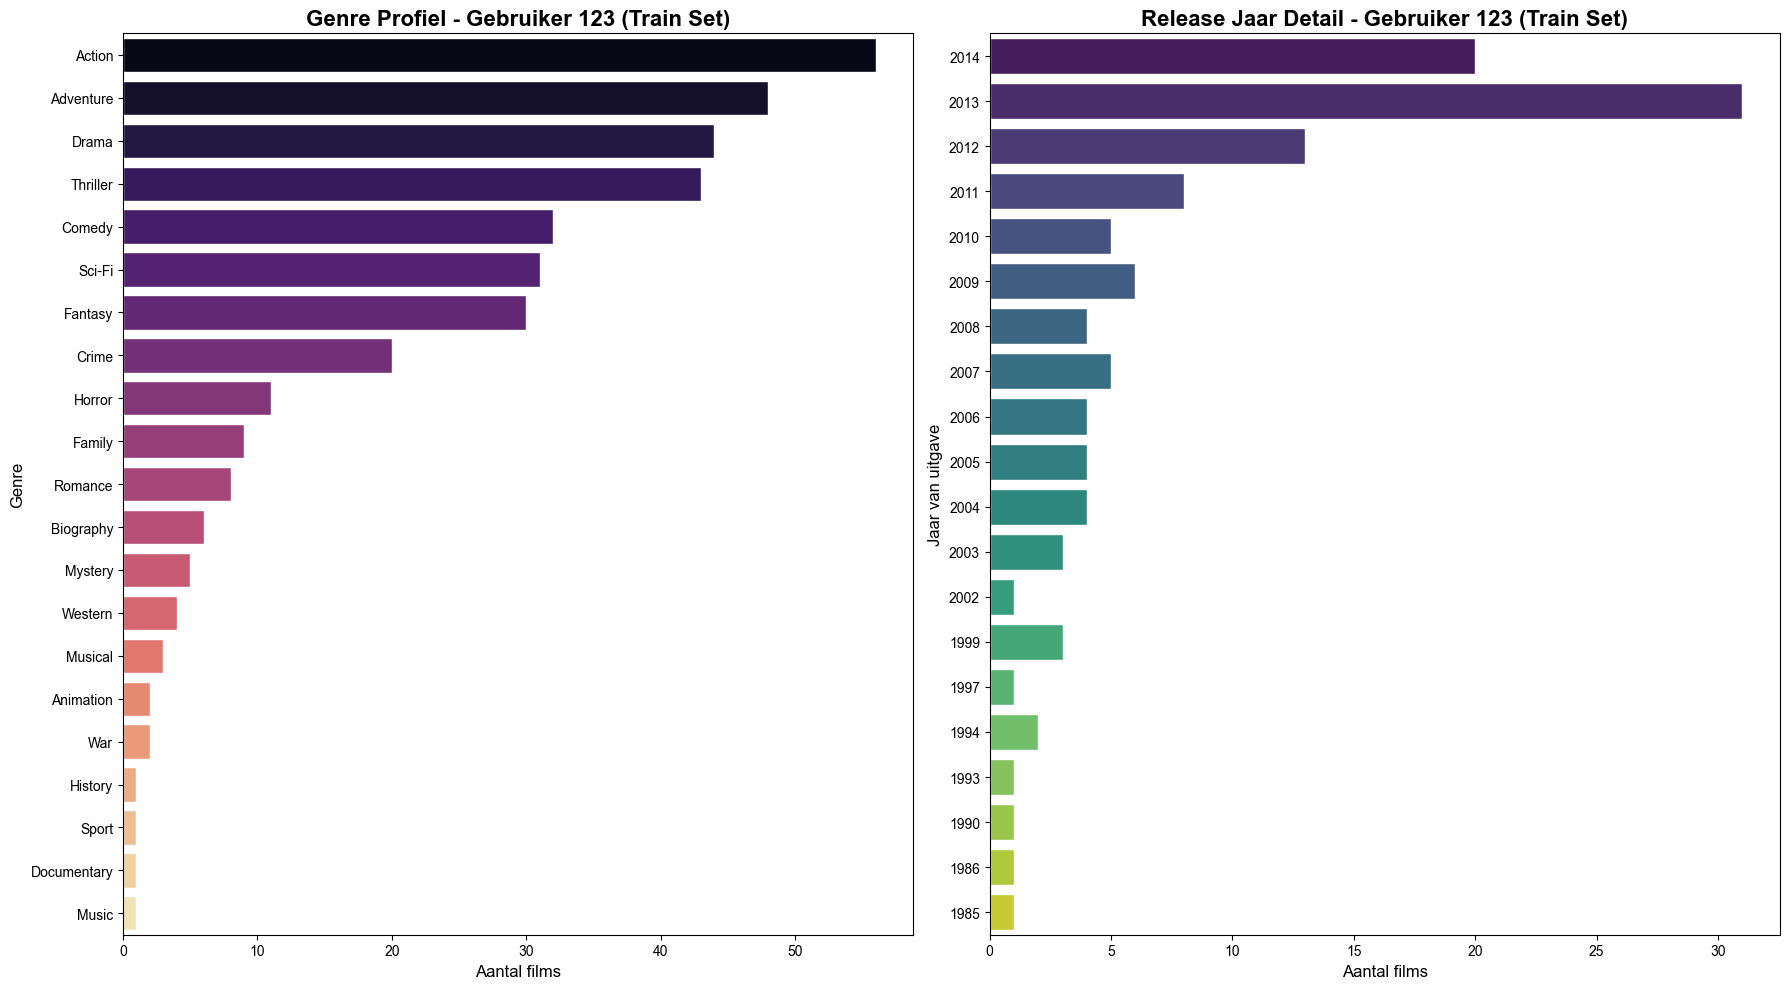

In [24]:
# 8.2.5 Plotten user profiel
plot_user_profile(123)

Hieronder zien we een voorbeeld van iemand die minder films heeft gezien en dus gewoon de top 3 films krijgt aangeraden. 


████████████████████████████████████████████████████████████████████████████████
███████████████████████ EVALUATIE RAPPORT: GEBRUIKER 456 ███████████████████████
████████████████████████████████████████████████████████████████████████████████

[TOP 3 AANBEVELINGEN]
--------------------------------------------------------------------------------
1. Gravity (2013)                                     | ❌ [GEEN MATCH]
   Genres: Drama, Sci-Fi, Thriller
2. Interstellar (2014)                                | ❌ [GEEN MATCH]
   Genres: Adventure, Drama, Sci-Fi
3. The Wolf of Wall Street (2013)                     | ❌ [GEEN MATCH]
   Genres: Biography, Crime, Drama

[HISTORIE] Films gezien in de Train Set (2 stuks):
--------------------------------------------------------------------------------
         Title                                  Genres
 Lilitu (2015)                         Short, Thriller
Psychos (2015) Crime, Drama, Horror, Mystery, Thriller

[WERKELIJKHEID] Werkelijk gekeken 

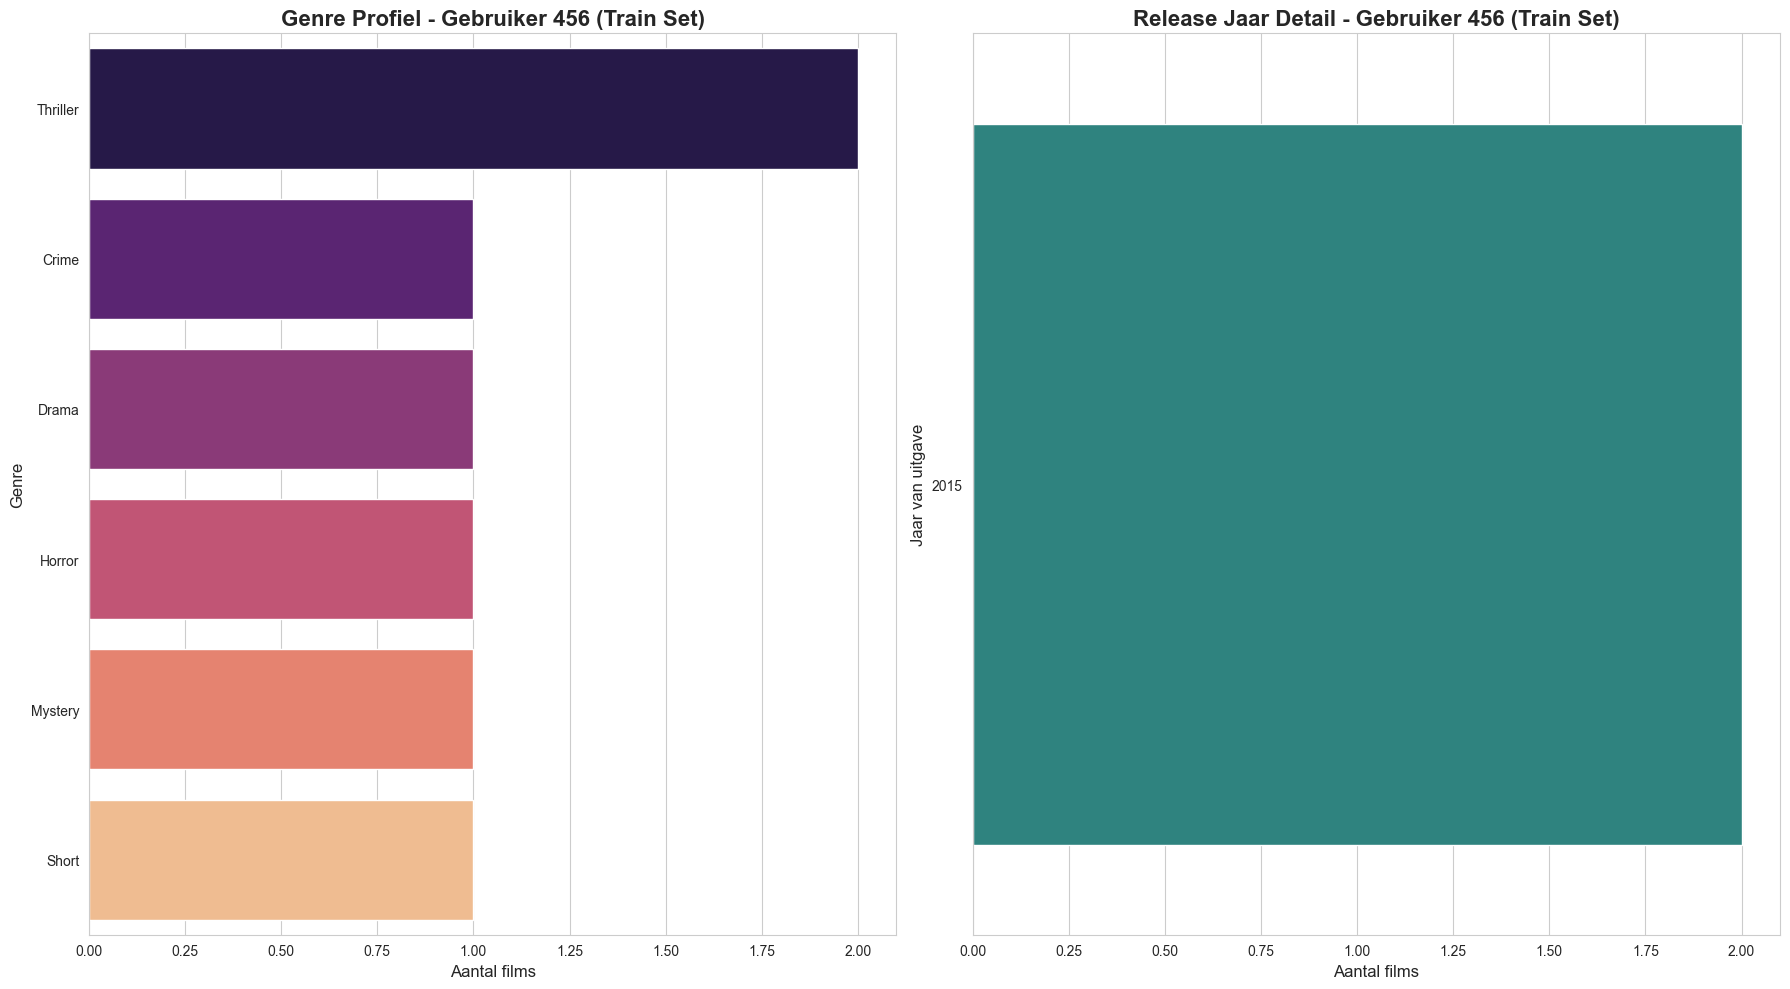

In [25]:
#8.2.6 User 456 analytics
get_user_report(456, recommendations)
plot_user_profile(456)


Hieronder weer een interesante waarneming. We zien aanbevelingen uit 2015 en 2016 en voornamelijk dramas, kijk je in de historische data dan zie je ook dat deze variabelen het meest voorkomen. Nog maals een succes! Al heeft het model weer een precision van 0 behaald op deze user is het mogelijk toch een goede aanbeveling.


████████████████████████████████████████████████████████████████████████████████
██████████████████████ EVALUATIE RAPPORT: GEBRUIKER 1241 ███████████████████████
████████████████████████████████████████████████████████████████████████████████

[TOP 3 AANBEVELINGEN]
--------------------------------------------------------------------------------
1. Spotlight (2015)                                   | ❌ [GEEN MATCH]
   Genres: Crime, Drama
2. Room (2015)                                        | ❌ [GEEN MATCH]
   Genres: Drama, Thriller
3. La La Land (2016)                                  | ❌ [GEEN MATCH]
   Genres: Comedy, Drama, Music, Musical, Romance

[HISTORIE] Films gezien in de Train Set (39 stuks):
--------------------------------------------------------------------------------
                                           Title                                        Genres
                                  Arrival (2016)              Drama, Mystery, Sci-Fi, Thriller
              

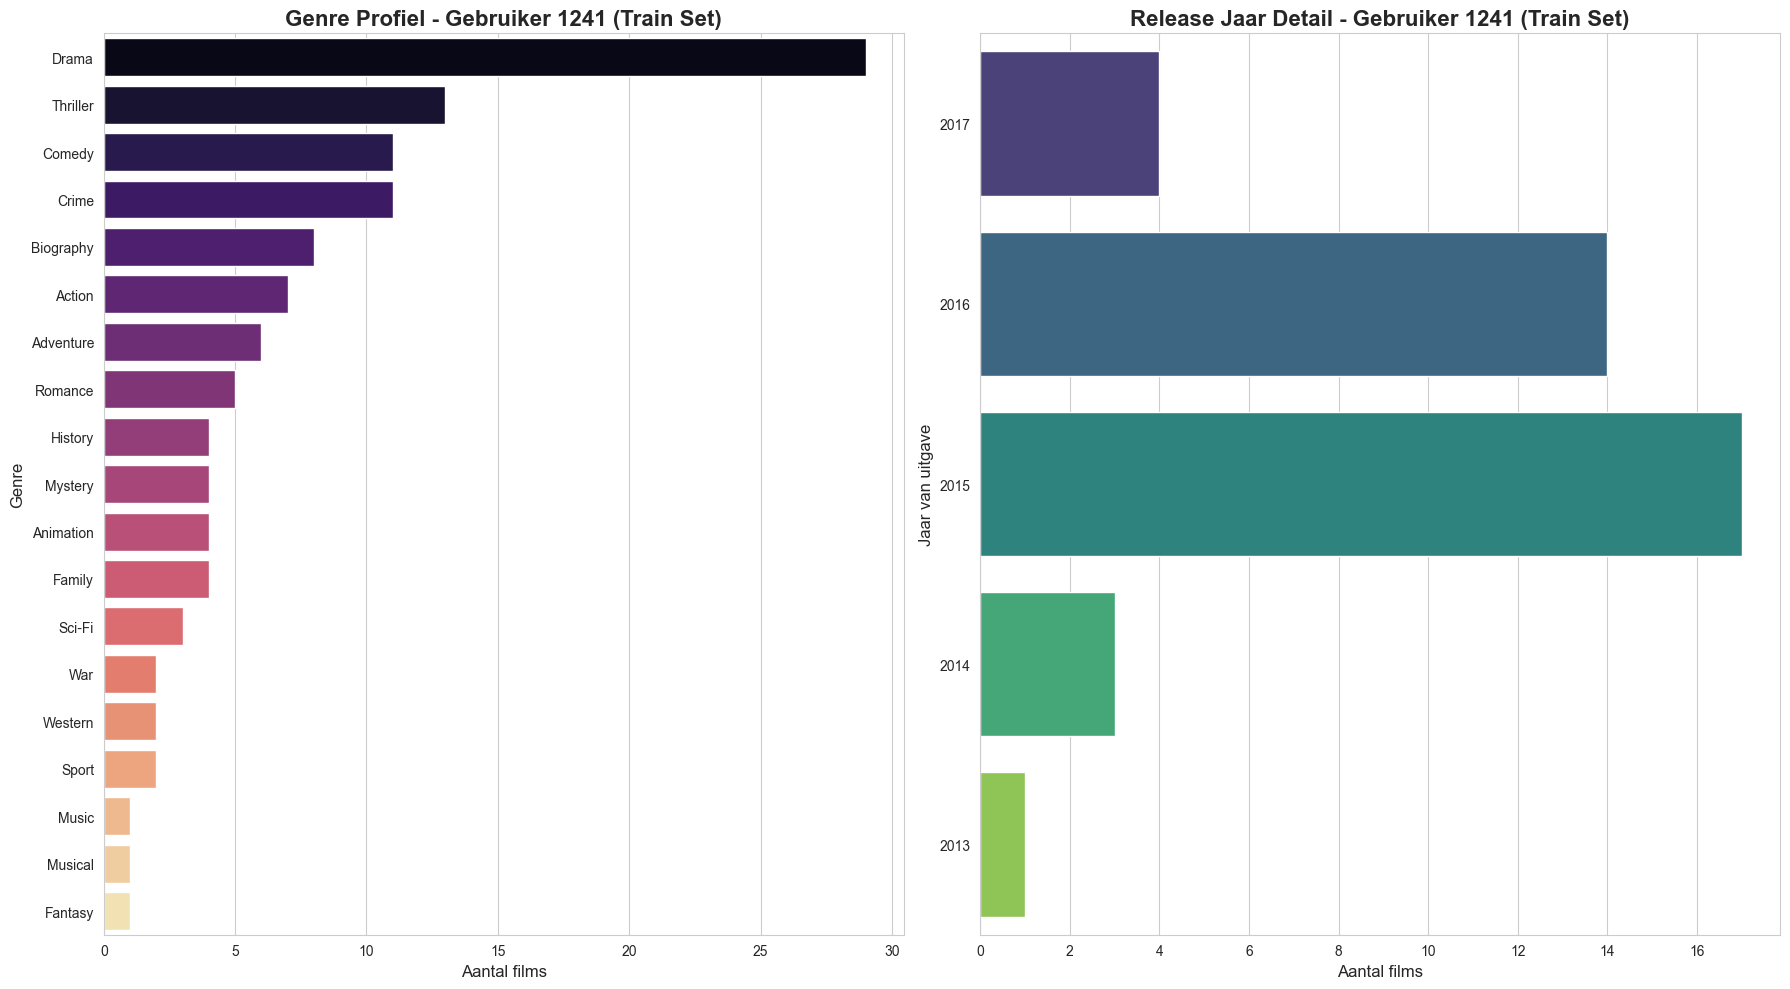

In [26]:
#8.2.7 User 1241 analytics
get_user_report(1241, recommendations)
plot_user_profile(1241)


Hier de Legendarische user die de meeste films heeft gezien van iedereen in de dataset. overeenkomsten tussen aanbevelingen en historische data zijn Drama Thriller en 2012.


████████████████████████████████████████████████████████████████████████████████
██████████████████████ EVALUATIE RAPPORT: GEBRUIKER 17405 ██████████████████████
████████████████████████████████████████████████████████████████████████████████

[TOP 3 AANBEVELINGEN]
--------------------------------------------------------------------------------
1. Life of Pi (2012)                                  | 🎯 [MATCH!]
   Genres: Adventure, Drama, Fantasy
2. Jack Reacher (2012)                                | 🎯 [MATCH!]
   Genres: Action, Crime, Thriller
3. Gangster Squad (2013)                              | ❌ [GEEN MATCH]
   Genres: Action, Crime, Drama, Thriller

[HISTORIE] Films gezien in de Train Set (118 stuks):
--------------------------------------------------------------------------------
                                                    Title                                              Genres
                                          10 Years (2011)                              C

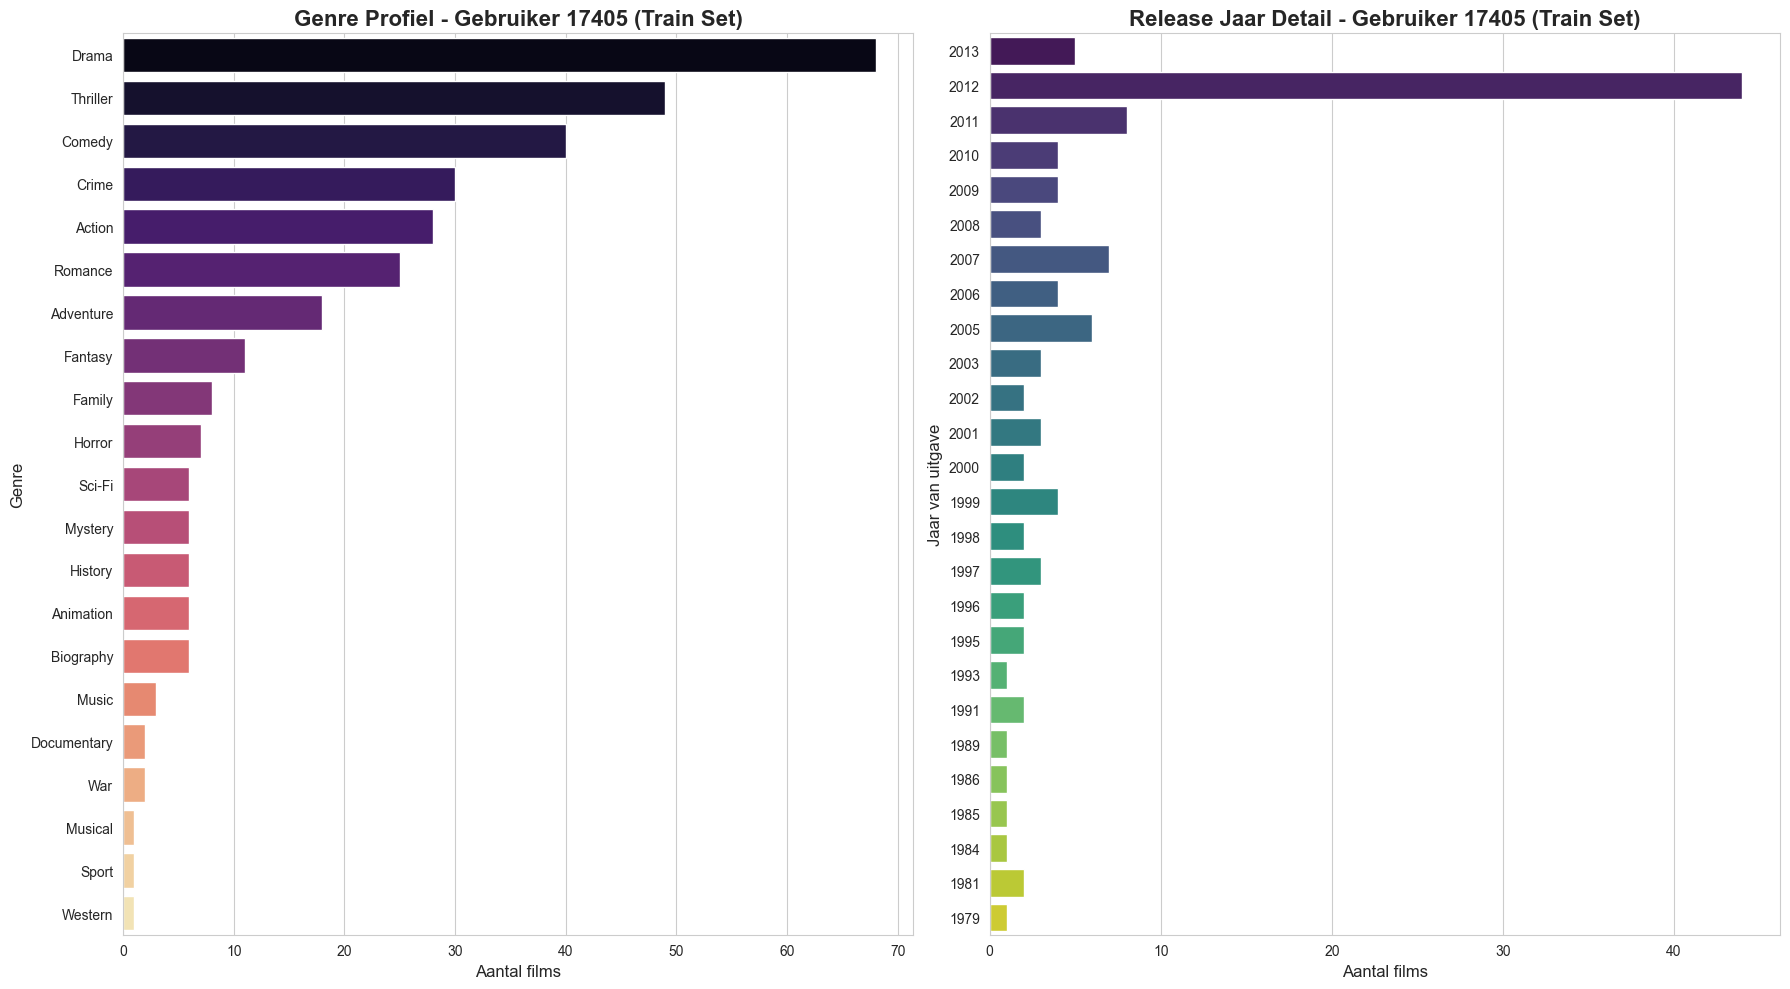

In [ ]:
#8.2.8 User 17405 analytics
get_user_report(17405, recommendations)
plot_user_profile(17405)

## 8.3 Mezelf Films Aanraden
Ik heb het eerder al gehad over het dillemma dat we wel films kunnen recommenden, maar we evalueren op data dat niet tot stand komt uit mij recomendations. We hebben geen "echte user feedback", en daarom is het hele evaluatie proces al minder accuraat. Maar ik heb een idee verzonnen om daadwerkelijk live user feedback te verzamelen. Dit ga ik doen door mijzelf en Jochem (mijn klasgenoot) films aan te raden op basis van de films die wij gerate hebben. Vervolgens ga ik deze users vragen wat zij van de recomendations vinden.

Ik ben de afgelopen 4 uur door movies.dat gaan scrollen, scrollen door IMDB top 50 lijsten van de jaren 2003 tot en met 2021. (data in movies.dat is tot en met 2021, maand x), en heb goed nagedacht over alle films die ik heb gezien of ooit nog wil zien. Vast een heleboel gemist maar de films die me het meest zijn bijgebleven staan erin. Ik weet natuurlijk niet de exacte datum waarop ik de films heb gekeken maar wel ongeveer het jaar dus heb ik als datum gebruikt: `01/01/JAAR`

Ik heb nu dus een trainset gemaakt met alle films die ik gezien heb, welk jaar ik ze heb gekeken en de beoordeling die ik ze zou geven. In de validatie set heb ik films gezet die mij interessant lijken en films die ik nog wil kijken. Nu vraag ik mij af of mijn model dus films kan raden die ik nog wil kijken

In [28]:
#8.3.1 Eigen data preparen
import pandas as pd
from datetime import datetime

MY_USER_ID = 999999

# Je 'Seen' data met jaren
my_seen_raw = [
    (110357, 2005, 9), (450259, 2006, 7), (99785, 2006, 7), (266543, 2008, 8),
    (345950, 2008, 10), (1193516, 2008, 7), (198781, 2009, 10), (1373215, 2009, 7),
    (1577061, 2010, 7), (385002, 2010, 10), (317219, 2010, 10), (892769, 2010, 9),
    (1155076, 2011, 9), (1711465, 2011, 7), (2084934, 2012, 7), (1232829, 2012, 7),
    (1409024, 2012, 8), (2355823, 2012, 8), (1675434, 2012, 8), (1800372, 2012, 10),
    (1453405, 2013, 10), (2472432, 2013, 10), (372824, 2013, 10), (443274, 2013, 7),
    (152930, 2013, 6), (1428538, 2013, 6), (3477064, 2014, 8), (2120120, 2015, 9),
    (499549, 2015, 4), (2279373, 2015, 7), (4974684, 2015, 8), (3522806, 2016, 5),
    (3531824, 2017, 10), (1700841, 2017, 7), (938283, 2017, 4), (1386697, 2017, 3),
    (74896, 2017, 10), (1396484, 2017, 6), (3401882, 2018, 6), (2737304, 2018, 6),
    (3118452, 2019, 2), (1677720, 2019, 9), (8228288, 2019, 8), (4823776, 2020, 7),
    (6105098, 2021, 7), (2294629, 2022, 7), (2283362, 2022, 8), (158983, 2023, 7),
    (298203, 2024, 10), (816692, 2025, 9), (1648112, 2025, 10), (2043932, 2025, 9),
    (1375666, 2026, 7)
]

# Functie om jaar om te zetten naar timestamp
def year_to_timestamp(year):
    dt = datetime(year, 1, 1)
    return int(dt.timestamp())

# Maak de dataframe
data_list = []
for m_id, year, rating in my_seen_raw:
    data_list.append({
        'User_ID': MY_USER_ID,
        'Movie_ID': m_id,
        'Rating': rating,
        'Rating_Timestamp': year_to_timestamp(year)
    })

my_train_df = pd.DataFrame(data_list)

# Voeg 'nth_rating' toe (gesorteerd op timestamp)
my_train_df = my_train_df.sort_values('Rating_Timestamp')
my_train_df['nth_rating'] = range(1, len(my_train_df) + 1)
my_train_df.head()

,User_ID,Movie_ID,Rating,Rating_Timestamp,nth_rating
0,999999,110357,9,1104534000,1
1,999999,450259,7,1136070000,2
2,999999,99785,7,1136070000,3
3,999999,266543,8,1199142000,4
4,999999,345950,10,1199142000,5


In [29]:
# 8.3.2 Overzicht Eigen Film Historie - hierin kun je ook zien welke beoordeling ik geef per film
my_movies_named = my_train_df.merge(movies[['Movie_ID', 'Title', 'Genres']], on='Movie_ID', how='left')

# 2. Opschonen voor een fraai overzicht
my_movies_named['Genres'] = my_movies_named['Genres'].str.replace('|', ', ', regex=False)

# 3. Laat je persoonlijke "Film Dagboek" zien
print("--- MIJN PERSOONLIJKE FILM HISTORIE ---")
print(my_movies_named[['nth_rating', 'Title', 'Rating', 'Rating_Timestamp', 'Genres']].to_string(index=False))

--- MIJN PERSOONLIJKE FILM HISTORIE ---
 nth_rating                                           Title  Rating  Rating_Timestamp                                                 Genres
          1                            The Lion King (1994)       9        1104534000           Animation, Adventure, Drama, Family, Musical
          2                            Blood Diamond (2006)       7        1136070000                             Adventure, Drama, Thriller
          3                               Home Alone (1990)       7        1136070000                                         Comedy, Family
          4                             Finding Nemo (2003)       8        1199142000                   Animation, Adventure, Comedy, Family
          5          The SpongeBob SquarePants Movie (2004)      10        1199142000          Animation, Adventure, Comedy, Family, Fantasy
          6                             Recep Ivedik (2008)       7        1199142000                             

In [32]:
# 8.3.3 Mezelf toevoegen aan de train en val sets
# Voeg jezelf toe aan de bestaande train_data
train_data_with_me = pd.concat([train_data, my_train_df], ignore_index=True)

# Update de dictionaries die we gebruiken voor evaluatie
user_train_seen[MY_USER_ID] = set(my_train_df['Movie_ID'])

my_interested_ids = [] # ik ga zelf feedback geven

user_val_actual[MY_USER_ID] = my_interested_ids

In [36]:
#8.3.4 Matrix Factorization)
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

# Gebruik de dataset inclusief jouw ratings
user_counts = train_data_with_me['User_ID'].value_counts()
cf_users = user_counts[user_counts >= 20].index.tolist()

# Bouw de CF subset met jou erbij
train_cf = train_data_with_me[train_data_with_me['User_ID'].isin(cf_users)]

# De rest van deze blok blijft hetzelfde, maar werkt nu met 'train_cf' waar jij in zit
user_map = {id: i for i, id in enumerate(train_cf['User_ID'].unique())}
movie_map = {id: i for i, id in enumerate(train_cf['Movie_ID'].unique())}
inv_movie_map = {i: id for id, i in movie_map.items()}

# Sparse Matrix bouwen
row = train_cf['User_ID'].map(user_map)
col = train_cf['Movie_ID'].map(movie_map)
data = train_cf['Rating']
rating_matrix = csr_matrix((data, (row, col)), shape=(len(user_map), len(movie_map)))

U, sigma, Vt = svds(rating_matrix.astype(float), k=50)
sigma = np.diag(sigma)
all_user_predicted_ratings = np.dot(np.dot(U, sigma), Vt)

# 4. De Aanbevelingsfunctie
def get_hybrid_rec(user_id):
    seen = user_train_seen.get(user_id, set())
    
    # CASE 1: Gebruiker heeft >= 20 ratings -> Matrix Factorization
    if user_id in user_map:
        idx = user_map[user_id]
        user_ratings = all_user_predicted_ratings[idx]
        
        # Sorteer movie indices op basis van voorspelde score
        movie_indices = np.argsort(-user_ratings)
        
        recommended = []
        for i in movie_indices:
            m_id = inv_movie_map[i]
            if m_id not in seen:
                recommended.append(m_id)
            if len(recommended) == 50:
                break
        return recommended
    
    # CASE 2: Gebruiker heeft < 20 ratings (of onbekend) -> Popularity Baseline
    else:
        recommended = [m for m in top_50_popular_ids if m not in seen]
        return recommended[:50]

# Check of je ID al in de array zit
if MY_USER_ID not in alle_users:
    # NumPy manier om een waarde toe te voegen: np.append()
    alle_users = np.append(alle_users, MY_USER_ID)

# De rest van de code kan gewoon blijven staan
user_train_seen[MY_USER_ID] = set(my_train_df['Movie_ID'])

# 5. Pas toe op ALLE gebruikers
recommendations2 = {u_id: get_hybrid_rec(u_id) for u_id in alle_users}

*Zie output #8.3.5 Mijn eerste perssonlijke rapport en profiel* Dit is toch gaaf. Toevallig heb ik despicable me 2 (verschrikkelijke ikke 2) wel gezien maar das al zo lang geleden zou het waarschijnlijk een 7 geven. Big Hero 6 heb ik vaak op reclames gezien maar trok niet perse mijn interesse. The Lego Movie zag ik net tijdens het scrollen door movies.dat maar trok ook niet perse mijn interesse. Interessant om te zien hoe dat de genre "animation" op nummer 7 staat maar toch vaak voorkomen. Dit zal hoogstwaarschijnlijk komen omdat ik veel animatie films erg hoge scores heb gegeven. *Zie output #8.3.2 Overzicht eigen film historie*

In [ ]:
#8.3.5 Rapport per Gebruiker functie
def get_user_report_no_match(user_id, recommendations_dict):
    # 1. Haal de IDs op
    train_ids = list(user_train_seen.get(user_id, []))
    rec_ids = recommendations_dict.get(user_id, [])
    val_ids = list(user_val_actual.get(user_id, []))
    
    # 2. Helper om film info op te halen
    def get_info(id_list):
        if not id_list: return None
        df = movies[movies['Movie_ID'].isin(id_list)].copy()
        df['Genres'] = df['Genres'].str.replace('|', ', ', regex=False)
        return df

    print("\n" + "█"*80)
    print(f" EVALUATIE RAPPORT: GEBRUIKER {user_id} ".center(80, "█"))
    print("█"*80)

    # SECTIE 1: TOP 3 RECOMMENDATIONS (Met Match check)
    print(f"\n[TOP 50 AANBEVELINGEN]")
    print("-" * 80)
    
    rec_info = get_info(rec_ids)
    if rec_info is not None:
        for i, m_id in enumerate(rec_ids, 1):
            row = rec_info[rec_info['Movie_ID'] == m_id]
            if not row.empty:
                title = row['Title'].values[0]
                genres = row['Genres'].values[0]
                # Check of dit een match is met de validatieset
                print(f"{i}. {title:<50}")
                print(f"   Genres: {genres}")
    else:
        print("Geen aanbevelingen beschikbaar.")

    # SECTIE 2: HISTORIE (TRAIN SET)
    print("\n" + "="*80)
    print(f"[HISTORIE] Films gezien in de Train Set ({len(train_ids)} stuks):")
    print("-" * 80)
    train_info = get_info(train_ids)
    if train_info is not None:
        print(train_info[['Title', 'Genres']].sort_values('Title').to_string(index=False))
    else:
        print("Geen historie gevonden.")

    # SECTIE 3: WERKELIJKHEID (VALIDATIE SET)
    print("\n" + "="*80)
    print(f"[WERKELIJKHEID] Werkelijk gekeken in Validatie Set ({len(val_ids)} stuks):")
    print("-" * 80)
    val_info = get_info(val_ids)
    if val_info is not None:
        print(val_info[['Title', 'Genres']].sort_values('Title').to_string(index=False))
    else:
        print("Deze gebruiker heeft geen nieuwe films gekeken in de validatieperiode.")

    print("\n" + "█"*80)


████████████████████████████████████████████████████████████████████████████████
█████████████████████ EVALUATIE RAPPORT: GEBRUIKER 999999 ██████████████████████
████████████████████████████████████████████████████████████████████████████████

[TOP 50 AANBEVELINGEN]
--------------------------------------------------------------------------------
1. Despicable Me 2 (2013)                            
   Genres: Animation, Adventure, Comedy, Family, Fantasy, Sci-Fi
2. Big Hero 6 (2014)                                 
   Genres: Animation, Action, Adventure, Comedy, Family, Sci-Fi
3. The Lego Movie (2014)                             
   Genres: Animation, Action, Adventure, Comedy, Family, Fantasy
4. Inside Out (2015)                                 
   Genres: Animation, Adventure, Comedy, Drama, Family, Fantasy
5. The Shawshank Redemption (1994)                   
   Genres: Drama
6. Despicable Me (2010)                              
   Genres: Animation, Comedy, Family, Fantasy
7. The

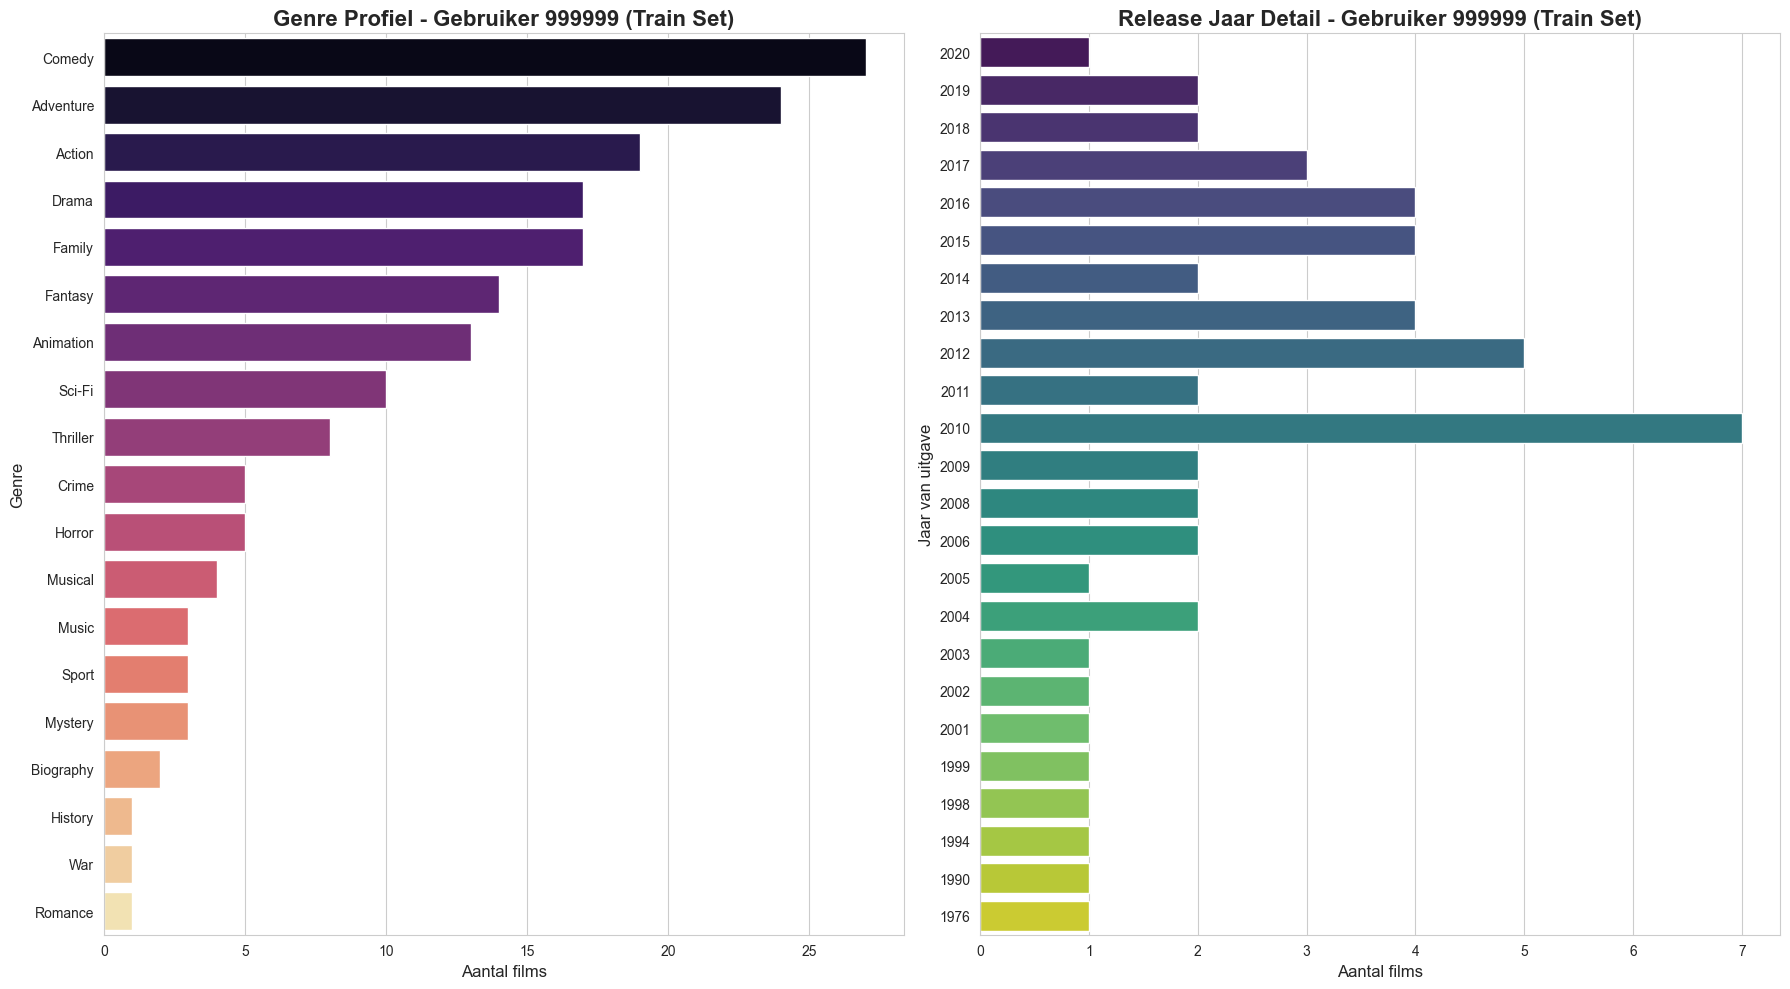

In [ ]:
# 8.3.6 Mijn eerste perssonlijke rapport en profiel
get_user_report_no_match(MY_USER_ID, recommendations2)
plot_user_profile(MY_USER_ID)

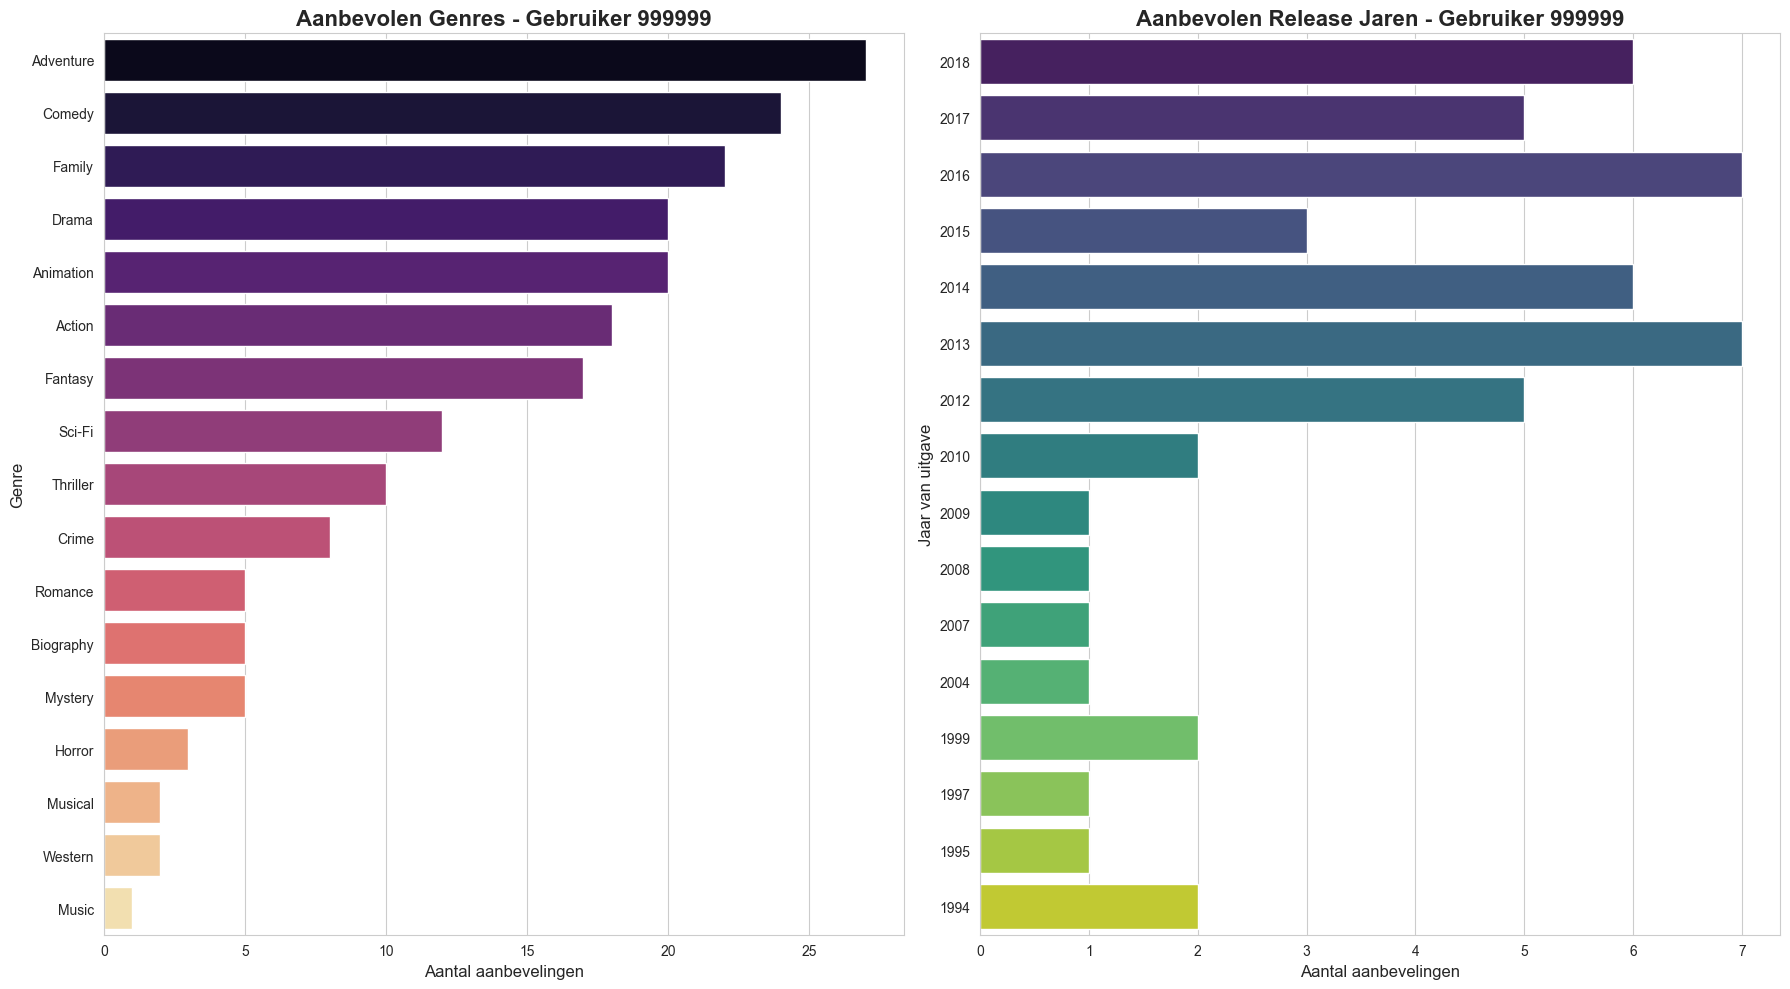

In [ ]:
#8.3.7 Plotten van mijn aanbevelingsprofiel
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

def plot_recommendation_profile(user_id, recommendations_list):
    # 1. Haal de aanbevolen films op uit movies.dat
    # Gebruik de MovieID en Title_with_Year kolommen uit jouw movies_dat
    movies_dat = pd.read_csv(
        "movies.dat",
        sep="::",
        engine="python",
        names=["MovieID", "Title_with_Year", "Genres_dat"]
    )
    rec_movies = movies_dat[movies_dat['MovieID'].isin(recommendations_list)].copy()

    if rec_movies.empty:
        print("Geen aanbevelingen gevonden in de dataset.")
        return

    # 2. Genres verwerken
    all_genres = []
    # In movies.dat zijn genres gescheiden door | (bv. Drama|Thriller)
    for g_str in rec_movies['Genres_dat']:
        all_genres.extend(g_str.split('|'))
    genre_counts = pd.Series(all_genres).value_counts()

    # 3. Jaren verwerken (Extractie uit Title_with_Year)
    def extract_year(title):
        match = re.search(r'\((\d{4})\)', str(title))
        return int(match.group(1)) if match else None

    rec_movies['Year'] = rec_movies['Title_with_Year'].apply(extract_year)
    # Sorteer jaren van nieuw naar oud voor de verticale as
    year_counts = rec_movies['Year'].value_counts().sort_index(ascending=False)

    # 4. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))
    sns.set_style("whitegrid")

    # Plot A: Aanbevolen Genres
    sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=ax1, palette="magma", hue=genre_counts.index, legend=False)
    ax1.set_title(f'Aanbevolen Genres - Gebruiker {user_id}', fontsize=16, fontweight='bold')
    ax1.set_xlabel('Aantal aanbevelingen', fontsize=12)
    ax1.set_ylabel('Genre', fontsize=12)

    # Plot B: Aanbevolen Release Jaren
    sns.barplot(x=year_counts.values, y=year_counts.index.astype(str), ax=ax2, palette="viridis", hue=year_counts.index.astype(str), legend=False)
    ax2.set_title(f'Aanbevolen Release Jaren - Gebruiker {user_id}', fontsize=16, fontweight='bold')
    ax2.set_xlabel('Aantal aanbevelingen', fontsize=12)
    ax2.set_ylabel('Jaar van uitgave', fontsize=12)

    plt.tight_layout()
    plt.show()

# Gebruik de functie voor je vriend
recommendations_my = recommendations2[MY_USER_ID]
plot_recommendation_profile(MY_USER_ID, recommendations_my)

Nou, ik heb 50 films gerecommend dit keer want ik was te nieuwsgierig wat de tool me zou recommenden *zie output #8.3.6* (misschien dat ik nog iets leuks zag). Ik probeer het kort te houden omdat we langzaamaan van de odpracht af driften. (Ik ben best kieskeurig met films kijken vooral de laatse paar jaar). Redelijk aantal matches 19/50. dat komt uit op een precision van `19/50*100=38% precision`. Ik krijg veel animatiefilms aangeraden die ik misschien als kind wel zou willen kijken maar wat me nu niet echt meer trekt. Zitten ook erg veel titels in die ik wel herken maar niet echt de behoefde heb om ze te kijken. Als we kijken naar de aangeraden genres en de genres die ik gekeken *(zie output #8.3.7)* heb zien we in beide gevallen in de top 2 adventure en comedy staan. kijken we naar de jaartallen van de films aangeraden en gekeken zien we niet perse een duidlijke correlatie.

- ❌ (31) = Slechte recomendation
- ✅ (13) = Goede recomendation
- 🟦 (6) = Al gezien dus eigenlijk ook goed

1. 🟦 Despicable Me 2 (2013) Genres: Animation, Adventure, Comedy, Family, Fantasy, Sci-Fi
2. ❌ Big Hero 6 (2014) Genres: Animation, Action, Adventure, Comedy, Family, Sci-Fi
3. ❌ The Lego Movie (2014) Genres: Animation, Action, Adventure, Comedy, Family, Fantasy
4. 🟦 Inside Out (2015) Genres: Animation, Adventure, Comedy, Drama, Family, Fantasy
5. ✅ The Shawshank Redemption (1994) Genres: Drama
6. 🟦 Despicable Me (2010) Genres: Animation, Comedy, Family, Fantasy
7. ❌ The Croods (2013) Genres: Animation, Action, Adventure, Comedy, Family, Fantasy
8. ❌ Coco (2017) Genres: Animation, Adventure, Comedy, Family, Fantasy, Music, Mystery
9. ✅ Forrest Gump (1994) Genres: Drama, Romance
10. 🟦 How to Train Your Dragon 2 (2014) Genres: Animation, Action, Adventure, Comedy, Family, Fantasy
11. ❌ The Dark Knight (2008) Genres: Action, Crime, Drama, Thriller
12. ❌ The Revenant (2015) Genres: Action, Adventure, Biography, Drama, Western
13. ❌ Zootopia (2016) Genres: Animation, Adventure, Comedy, Crime, Family, Mystery
14. ❌ Wreck-It Ralph (2012) Genres: Animation, Adventure, Comedy, Family, Fantasy
15. ✅ The Hunger Games (2012) Genres: Action, Adventure, Sci-Fi, Thriller
16. ✅ Up (2009) Genres: Animation, Adventure, Comedy, Family
17. ❌ Her (2013) Genres: Drama, Romance, Sci-Fi
18. ❌ Maleficent (2014) Genres: Action, Adventure, Family, Fantasy, Romance
19. ❌ The Greatest Showman (2017) Genres: Biography, Drama, Musical
20. ❌ Deadpool 2 (2018) Genres: Action, Adventure, Comedy, Sci-Fi
21. ❌ Sully (2016) Genres: Biography, Drama
22. ✅ Toy Story (1995) Genres: Animation, Adventure, Comedy, Family, Fantasy
23. ❌ A Quiet Place (2018) Genres: Drama, Horror, Sci-Fi
24. 🟦 Finding Dory (2016) Genres: Animation, Adventure, Comedy, Family
25. ✅ Toy Story 3 (2010) Genres: Animation, Adventure, Comedy, Family, Fantasy
26. ❌ Life of Pi (2012) Genres: Adventure, Drama, Fantasy
27. ❌ The Martian (2015) Genres: Adventure, Drama, Sci-Fi
28. ❌ We're the Millers (2013) Genres: Comedy, Crime
29. ❌ Don't Breathe (2016) Genres: Crime, Horror, Thriller
30. ❌ Wonder (2017) Genres: Drama, Family
31. ❌ Dallas Buyers Club (2013) Genres: Biography, Drama
32. ❌ Venom (2018) Genres: Action, Sci-Fi, Thriller
33. ✅ Game Night (2018) Genres: Action, Comedy, Crime, Mystery
34. ❌ The Secret Life of Walter Mitty (2013) Genres: Adventure, Comedy, Drama, Fantasy, Romance
35. 🟦 Ratatouille (2007) Genres: Animation, Adventure, Comedy, Drama, Family, Fantasy
36. ❌ The Wolf of Wall Street (2013) Genres: Biography, Crime, Drama
37. ❌ Logan (2017) Genres: Action, Drama, Sci-Fi, Thriller
38. ✅ Mission: Impossible - Fallout (2018) Genres: Action, Adventure, Thriller
39. ❌ Incredibles 2 (2018) Genres: Animation, Action, Adventure, Family, Sci-Fi
40. ❌ The Incredibles (2004) Genres: Animation, Action, Adventure, Family
41. ❌ Contratiempo (2016) Genres: Crime, Mystery, Thriller
42. ✅ Django Unchained (2012) Genres: Drama, Western
43. ❌ The Hitman's Bodyguard (2017) Genres: Action, Comedy, Thriller
44. ✅ Toy Story 2 (1999) Genres: Animation, Adventure, Comedy, Family, Fantasy
45. ✅ Titanic (1997) Genres: Drama, Romance
46. ❌ Brave (2012) Genres: Animation, Adventure, Comedy, Family, Fantasy
47. ✅ The Maze Runner (2014) Genres: Action, Mystery, Sci-Fi, Thriller
48. ✅ The Matrix (1999) Genres: Action, Sci-Fi
49. ❌ Birdman (2014) Genres: Comedy, Drama
50. ❌ Vaiana (2016) Genres: Animation, Adventure, Comedy, Family, Fantasy, Musical

## 8.4 Jochem Films Aanraden
Aangezien mijn film smaak best wel apart, en er vast een hoop bias in zal zitten omdat ik alle films zonet heb gerate, heb ik besloten om mijn model te testen op iemand anders. Jochem heeft zijn IMDB data naar me toe gestuurd. Nu vertaalt dit natuurlijk niet één op één met `movies.dat` dus heb ik met wat code en handmatig ervoor gezorgd dat Jochem zijn IMDB data vertaald kan worden naar bruikbare data voor mijn case.

> Het kan erop lijken dat mijn eigen data in de dataset is toegevoegd op dit punt, maar ik heb de code opnieuw gerund tot het blokje waar ik mezelf toevoeg zodat mijn data geen invloed kan hebben op Jochem zijn recomendations. Dit vind ik wel net zo eerlijk omdat ik Jochem zijn data niet heb toegevoegd in de dataset toen ik voor mezelf recomendations ging maken. Zie de stappen waar ik mezelf en jochem films recomend als testen op de testset

Hieronder zie je de IMDB data van Jochem

In [ ]:
# 8.4.1 Dataset inladen
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('jochem_imdb_data.csv')
df.head()

,Const,Your Rating,Date Rated,Title,Original Title,URL,Title Type,IMDb Rating,Runtime (mins),Year,Genres,Num Votes,Release Date,Directors
0,tt26584495,6,2026-02-05,Companion,Companion,https://www.imdb.com/title/tt26584495,Movie,6.9,97,2025,"Thriller, Sci-Fi",169400,2025-01-31,Drew Hancock
1,tt9253284,7,2026-01-03,Andor,Andor,https://www.imdb.com/title/tt9253284,TV Series,8.6,60,2022,"Sci-Fi, Thriller, Action, Adventure, Fantasy, ...",270142,2022-09-21,NaN
2,tt0113247,8,2026-01-01,La haine,La haine,https://www.imdb.com/title/tt0113247,Movie,8.1,98,1995,"Crime, Drama",223725,1996-02-23,Mathieu Kassovitz
3,tt0118929,8,2025-12-29,Dark City,Dark City,https://www.imdb.com/title/tt0118929,Movie,7.5,100,1998,"Thriller, Mystery, Fantasy, Sci-Fi",225141,1998-02-27,Alex Proyas
4,tt1196946,9,2025-10-07,The Mentalist,The Mentalist,https://www.imdb.com/title/tt1196946,TV Series,8.2,43,2008,"Drama, Crime, Mystery, Thriller",221777,2008-09-23,NaN


De dataset bevat ook series die Jochem heeft beoordeeld dus die moeten we weglaten, we kunnen ook heel veel andere kolommen weglaten die we niet nodig hebben uit de IMDB dataset

In [ ]:
# 8.4.2 Data opschonen
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('jochem_imdb_data.csv')

# 2. Filter for movies only
df_movies = df[df['Title Type'] == 'Movie'].copy()

# 3. Define the columns to drop
# Note: Matching the exact casing found in your dataset snippet
cols_to_drop = [
    "Const", 
    "Directors", 
    "Num Votes", 
    "Runtime (mins)", 
    "IMDb Rating", 
    "Title Type",
    "URL",
    "Release Date"
]

# 4. Drop the columns
df_cleaned = df_movies.drop(columns=cols_to_drop)

# Save the cleaned version to a new file
df_cleaned.to_csv('jochem_imdb_movies.csv', index=False)
df_cleaned.head()

,Your Rating,Date Rated,Title,Original Title,Year,Genres
0,6,2026-02-05,Companion,Companion,2025,"Thriller, Sci-Fi"
2,8,2026-01-01,La haine,La haine,1995,"Crime, Drama"
3,8,2025-12-29,Dark City,Dark City,1998,"Thriller, Mystery, Fantasy, Sci-Fi"
5,6,2025-09-13,A Working Man,A Working Man,2025,"Action, Thriller"
6,7,2025-09-12,The Boondock Saints,The Boondock Saints,1999,"Thriller, Action, Crime"


Nu kan ik de film titels in Jochem zijn dataset gebruiken om film titels op te zoeken in de movies.dat set om zo jochem zijn data te linken aan movie IDs 

In [ ]:
# 8.4.3 Data Mergen en Matchen
import pandas as pd
import re

# 1. Load Data
friend_df = pd.read_csv('jochem_imdb_movies.csv')
movie_cols = ['MovieID', 'Title_with_Year', 'Genres_dat']
movies_dat = pd.read_csv('movies.dat', sep='::', names=movie_cols, engine='python', encoding='ISO-8859-1')

# --- CLEANING ---
def clean_title(t):
    return str(t).lower().strip()

friend_df['clean_title'] = friend_df['Title'].apply(clean_title)
movies_dat['Year'] = movies_dat['Title_with_Year'].str.extract(r'\((\d{4})\)')
movies_dat['clean_title'] = movies_dat['Title_with_Year'].str.replace(r'\s\(\d{4}\)', '', regex=True).apply(clean_title)

friend_df['Year'] = friend_df['Year'].astype(str)
movies_dat['Year'] = movies_dat['Year'].astype(str)

# 2. MERGE
merged_df = pd.merge(friend_df, movies_dat, on=['clean_title', 'Year'], how='left')

# 3. FORMATTING
merged_df['Timestamp'] = pd.to_datetime(merged_df['Date Rated']).astype('int64') // 10**9

final_output = merged_df[[
    'MovieID', 
    'Title', 
    'Title_with_Year',
    'Year',
    'Your Rating', 
    'Timestamp'
]]

final_output.columns = ['MovieID', 'Friend_Title', 'Dataset_Title', 'Release_Year', 'Rating', 'Timestamp']

# --- FILTERING BY YEAR (NEW STEP) ---
# Convert to numeric (errors='coerce' handles any weird text, making them NaN)
final_output['Release_Year'] = pd.to_numeric(final_output['Release_Year'], errors='coerce')

# Drop anything after 2021
final_output = final_output[final_output['Release_Year'] <= 2021].copy()

# 4. IDENTIFY MISSING MATCHES
missing_matches = final_output[final_output['MovieID'].isna()]

print(f"Total movies (2021 and older): {len(final_output)}")
print(f"Successfully matched: {final_output['MovieID'].notna().sum()}")
print(f"Missing matches: {len(missing_matches)}")

if len(missing_matches) > 0:
    print("\n--- MOVIES YOU NEED TO FIX MANUALLY (Pre-2022) ---")
    print(missing_matches[['Friend_Title', 'Release_Year', 'Rating']])

# 5. SAVE
final_output.to_csv('friend_ratings_full_list.csv', index=False)

Total movies (2021 and older): 165
Successfully matched: 150
Missing matches: 15

--- MOVIES YOU NEED TO FIX MANUALLY (Pre-2022) ---
                                        Friend_Title  Release_Year  Rating
20                                  Mulholland Drive          2001       6
36                                     28 Days Later          2002       6
49                             The Resistance Banker          2018       7
82                              The Raid: Redemption          2011       8
91   Birdman or (The Unexpected Virtue of Ignorance)          2014       8
99                                       City of God          2002       9
108                                       12 Monkeys          1995       8
123        13 Hours: The Secret Soldiers of Benghazi          2016       8
135                                         Parasite          2019       6
137                 Once Upon a Time... in Hollywood          2019       6
145                           Léon: The Pr

Van de films die ik handmatig heb moeten oplossen heb ik het gros kunnen vinden omdat de titels dan in een andere taal stond in movies.dat. Helaas zijn de volgende films wel afgevallen omdat ik ze op geen enkele manier terug kon vinden
- Parasite (2019), Rating: 6
- The King's Man (2021), Rating: 6
- Dune / Dune: Part One (2021), Rating: 8

In [ ]:
# 8.4.4 Jochems Ultieme Dataset inladen en Sorteren
df_final = pd.read_csv('jochem_cleaned.csv')

# sorteren op Timestamp
df_final = df_final.sort_values(by='Timestamp', ascending=True)
df_final = df_final.reset_index(drop=True)

df_final.head()

,MovieID,Friend_Title,Dataset_Title,Release_Year,Rating,Timestamp
0,816692.0,Interstellar,Interstellar (2014),2014,9,1714089
1,1631867.0,Edge of Tomorrow,Edge of Tomorrow (2014),2014,7,1714089
2,1431045.0,Deadpool,Deadpool (2016),2016,8,1714089
3,416449.0,300,300 (2006),2006,6,1714089
4,936501.0,Taken,Taken (2008),2008,7,1714089


Nu de data van jochem volledig is geprepareerd kan ik Jochem toevoegen als user in de train data

In [ ]:
# 8.4.5 Jochems Data toevoegen aan de Train Set
import pandas as pd

# 1. Setup IDs
FRIEND_USER_ID = 999999  # A unique ID for your friend

# 2. Prepare Friend's Data
# Load the file we just created
friend_train_df = pd.read_csv('jochem_cleaned.csv')

# We also rename columns to match your existing train_data format
friend_train_df = friend_train_df.rename(columns={
    'MovieID': 'Movie_ID'
})

# Add the User_ID column
friend_train_df['User_ID'] = FRIEND_USER_ID

# Select only the columns that exist in your original train_data
# (Assuming the original has: User_ID, Movie_ID, Rating, Timestamp)
friend_train_df = friend_train_df[['User_ID', 'Movie_ID', 'Rating', 'Timestamp']]

# 3. CONCATENATE with the original training data
# Note: We are using the original 'train_data' as the starting point here
train_data_with_friend = pd.concat([train_data, friend_train_df], ignore_index=True)

# 4. UPDATE the 'seen' dictionary
# This ensures the model doesn't recommend movies he has already rated
user_train_seen[FRIEND_USER_ID] = set(friend_train_df['Movie_ID'])

# 5. Verify
print(f"Original train size: {len(train_data)}")
print(f"New train size with friend: {len(train_data_with_friend)}")
print(f"Friend's seen movies recorded: {len(user_train_seen[FRIEND_USER_ID])}")

Original train size: 737118
New train size with friend: 737280
Friend's seen movies recorded: 162


In [ ]:
# 8.4.6 Matrix Factorization met Jochems Data

import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds

# 1. Setup the ID for your friend
FRIEND_USER_ID = 999999 

# 2. Filter for users with enough data (>= 20 ratings)
# We use 'train_data_with_friend' (which does NOT include you)
user_counts = train_data_with_friend['User_ID'].value_counts()
cf_users = user_counts[user_counts >= 20].index.tolist()

# 3. Build the CF subset
train_cf = train_data_with_friend[train_data_with_friend['User_ID'].isin(cf_users)]

# 4. Map Users and Movies to matrix indices
user_map = {id: i for i, id in enumerate(train_cf['User_ID'].unique())}
movie_map = {id: i for i, id in enumerate(train_cf['Movie_ID'].unique())}
inv_movie_map = {i: id for id, i in movie_map.items()}

# 5. Build the Sparse Matrix
row = train_cf['User_ID'].map(user_map)
col = train_cf['Movie_ID'].map(movie_map)
data = train_cf['Rating']
rating_matrix = csr_matrix((data, (row, col)), shape=(len(user_map), len(movie_map)))

# 6. Perform SVD
# k=50 is the number of latent factors
U, sigma, Vt = svds(rating_matrix.astype(float), k=50)
sigma = np.diag(sigma)
all_user_predicted_ratings = np.dot(np.dot(U, sigma), Vt)

# 7. The Recommendation Function
def get_hybrid_rec(user_id):
    # Get movies this specific user has already seen
    seen = user_train_seen.get(user_id, set())
    
    # CASE 1: Matrix Factorization (User has >= 20 ratings)
    if user_id in user_map:
        idx = user_map[user_id]
        user_ratings = all_user_predicted_ratings[idx]
        
        # Sort movie indices by predicted score (descending)
        movie_indices = np.argsort(-user_ratings)
        
        recommended = []
        for i in movie_indices:
            m_id = inv_movie_map[i]
            if m_id not in seen:
                recommended.append(m_id)
            if len(recommended) == 50:
                break
        return recommended
    
    # CASE 2: Popularity Baseline (User has < 20 ratings)
    else:
        # Assuming top_50_popular_ids is defined from your earlier baseline code
        recommended = [m for m in top_50_popular_ids if m not in seen]
        return recommended[:50]

# 8. Add Friend to the evaluation list (replace alle_users logic)
if FRIEND_USER_ID not in alle_users:
    alle_users = np.append(alle_users, FRIEND_USER_ID)

# 9. Generate final recommendations
recommendations_final = {u_id: get_hybrid_rec(u_id) for u_id in alle_users}

# Show what we got for the friend!
print(f"Top 50 recommendations for Friend ({FRIEND_USER_ID}):")
print(recommendations_final[FRIEND_USER_ID])

Top 50 recommendations for Friend (999999):
[99685.0, 372784.0, 71562.0, 6751668.0, 2911666.0, 5027774.0, 169547.0, 2119532.0, 2084970.0, 469494.0, 113277.0, 133093.0, 112573.0, 50083.0, 1291584.0, 1091191.0, 119488.0, 2802144.0, 8367814.0, 1302006.0, 3170832.0, 3460252.0, 1951264.0, 443706.0, 1024648.0, 167404.0, 421715.0, 1396484.0, 112641.0, 120338.0, 120382.0, 118715.0, 60196.0, 105323.0, 217505.0, 162222.0, 2584384.0, 116282.0, 338013.0, 1205489.0, 88763.0, 2103281.0, 1670345.0, 405159.0, 76759.0, 103064.0, 9243946.0, 99674.0, 7653254.0, 1895587.0]


In [ ]:
#8.4.7 Rapport per Gebruiker functie
def get_user_report_no_match(user_id, recommendations_dict):
    # 1. Haal de IDs op
    train_ids = list(user_train_seen.get(user_id, []))
    rec_ids = recommendations_dict.get(user_id, [])
    val_ids = list(user_val_actual.get(user_id, []))
    
    # 2. Helper om film info op te halen
    def get_info(id_list):
        if not id_list: return None
        df = movies[movies['Movie_ID'].isin(id_list)].copy()
        df['Genres'] = df['Genres'].str.replace('|', ', ', regex=False)
        return df

    print("\n" + "█"*80)
    print(f" EVALUATIE RAPPORT: GEBRUIKER {user_id} ".center(80, "█"))
    print("█"*80)

    # SECTIE 1: TOP 3 RECOMMENDATIONS (Met Match check)
    print(f"\n[TOP 50 AANBEVELINGEN]")
    print("-" * 80)
    
    rec_info = get_info(rec_ids)
    if rec_info is not None:
        for i, m_id in enumerate(rec_ids, 1):
            row = rec_info[rec_info['Movie_ID'] == m_id]
            if not row.empty:
                title = row['Title'].values[0]
                genres = row['Genres'].values[0]
                # Check of dit een match is met de validatieset
                print(f"{i}. {title:<50}")
                print(f"   Genres: {genres}")
    else:
        print("Geen aanbevelingen beschikbaar.")

    # SECTIE 2: HISTORIE (TRAIN SET)
    print("\n" + "="*80)
    print(f"[HISTORIE] Films gezien in de Train Set ({len(train_ids)} stuks):")
    print("-" * 80)
    train_info = get_info(train_ids)
    if train_info is not None:
        print(train_info[['Title', 'Genres']].sort_values('Title').to_string(index=False))
    else:
        print("Geen historie gevonden.")

    # SECTIE 3: WERKELIJKHEID (VALIDATIE SET)
    print("\n" + "="*80)
    print(f"[WERKELIJKHEID] Werkelijk gekeken in Validatie Set ({len(val_ids)} stuks):")
    print("-" * 80)
    val_info = get_info(val_ids)
    if val_info is not None:
        print(val_info[['Title', 'Genres']].sort_values('Title').to_string(index=False))
    else:
        print("Deze gebruiker heeft geen nieuwe films gekeken in de validatieperiode.")

    print("\n" + "█"*80)


████████████████████████████████████████████████████████████████████████████████
█████████████████████ EVALUATIE RAPPORT: GEBRUIKER 999999 ██████████████████████
████████████████████████████████████████████████████████████████████████████████

[TOP 50 AANBEVELINGEN]
--------------------------------------------------------------------------------
1. Goodfellas (1990)                                 
   Genres: Biography, Crime, Drama
2. Batman Begins (2005)                              
   Genres: Action, Adventure
3. The Godfather: Part II (1974)                     
   Genres: Crime, Drama
4. Gisaengchung (2019)                               
   Genres: Drama
5. John Wick (2014)                                  
   Genres: Action, Crime, Thriller
6. Three Billboards Outside Ebbing, Missouri (2017)  
   Genres: Crime, Drama
7. American Beauty (1999)                            
   Genres: Drama
8. Hacksaw Ridge (2016)                              
   Genres: Biography, Drama, History, 

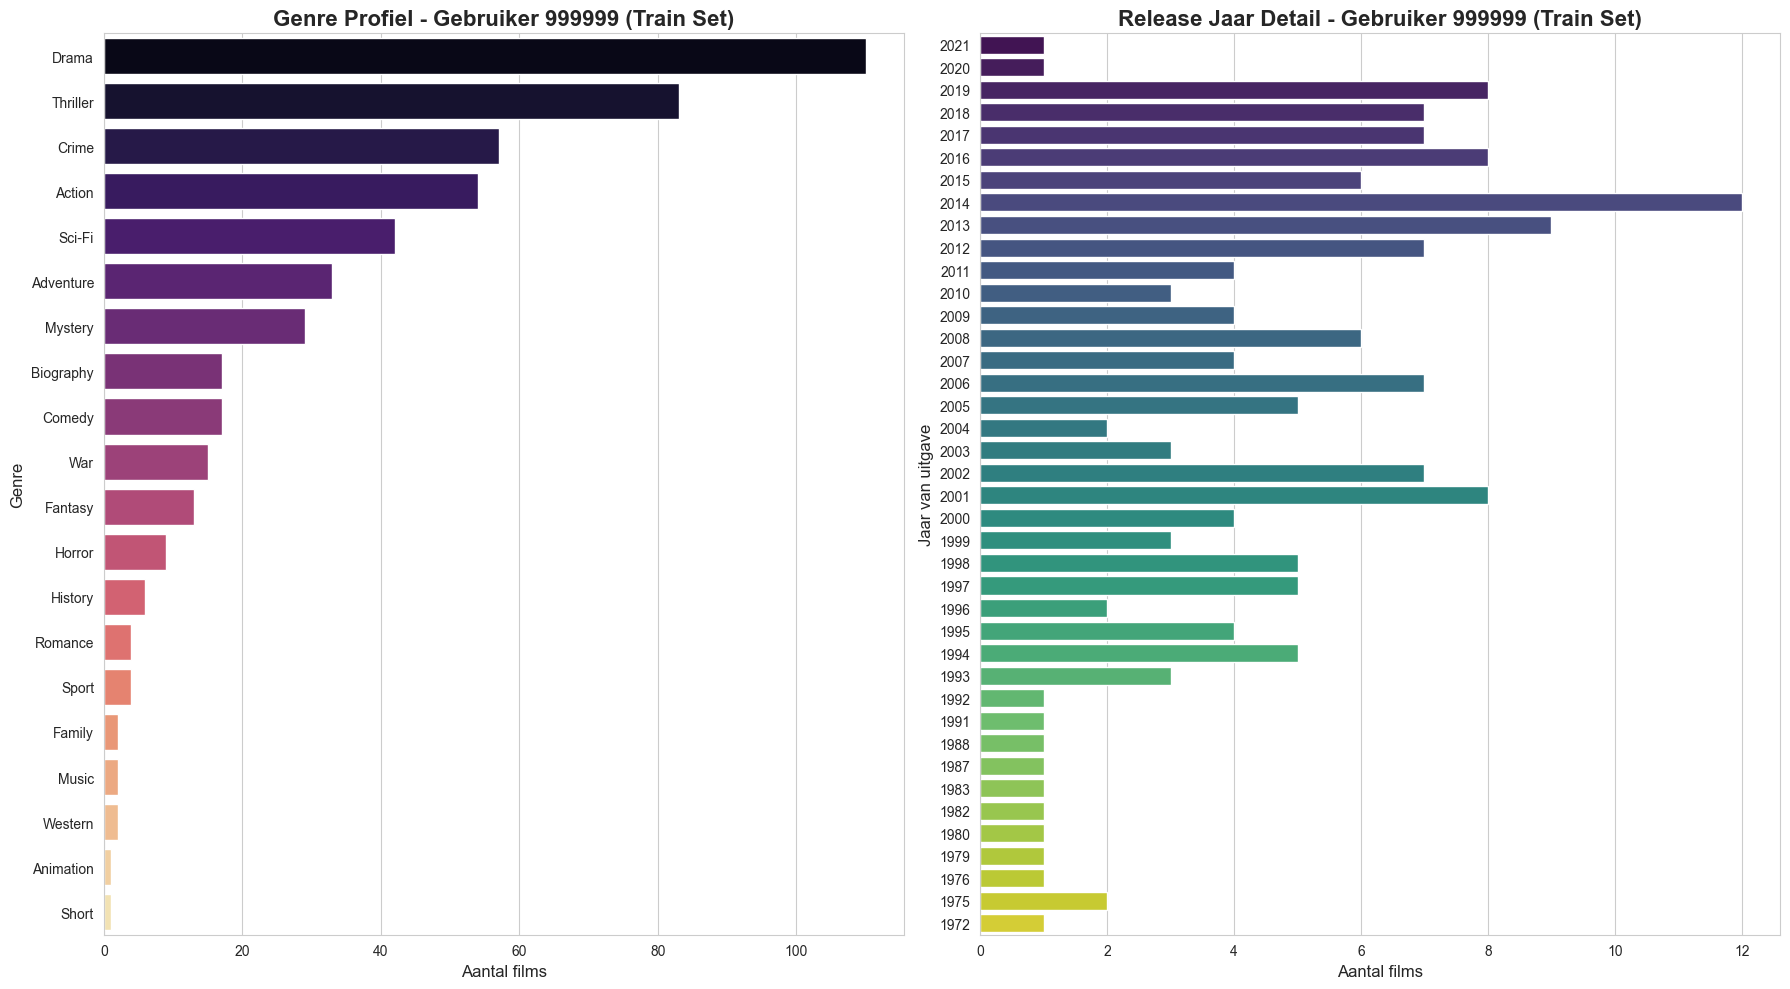

In [ ]:
# 8.4.8 Rapport en Profiel voor Jochem
get_user_report_no_match(FRIEND_USER_ID, recommendations_final)
plot_user_profile(FRIEND_USER_ID)

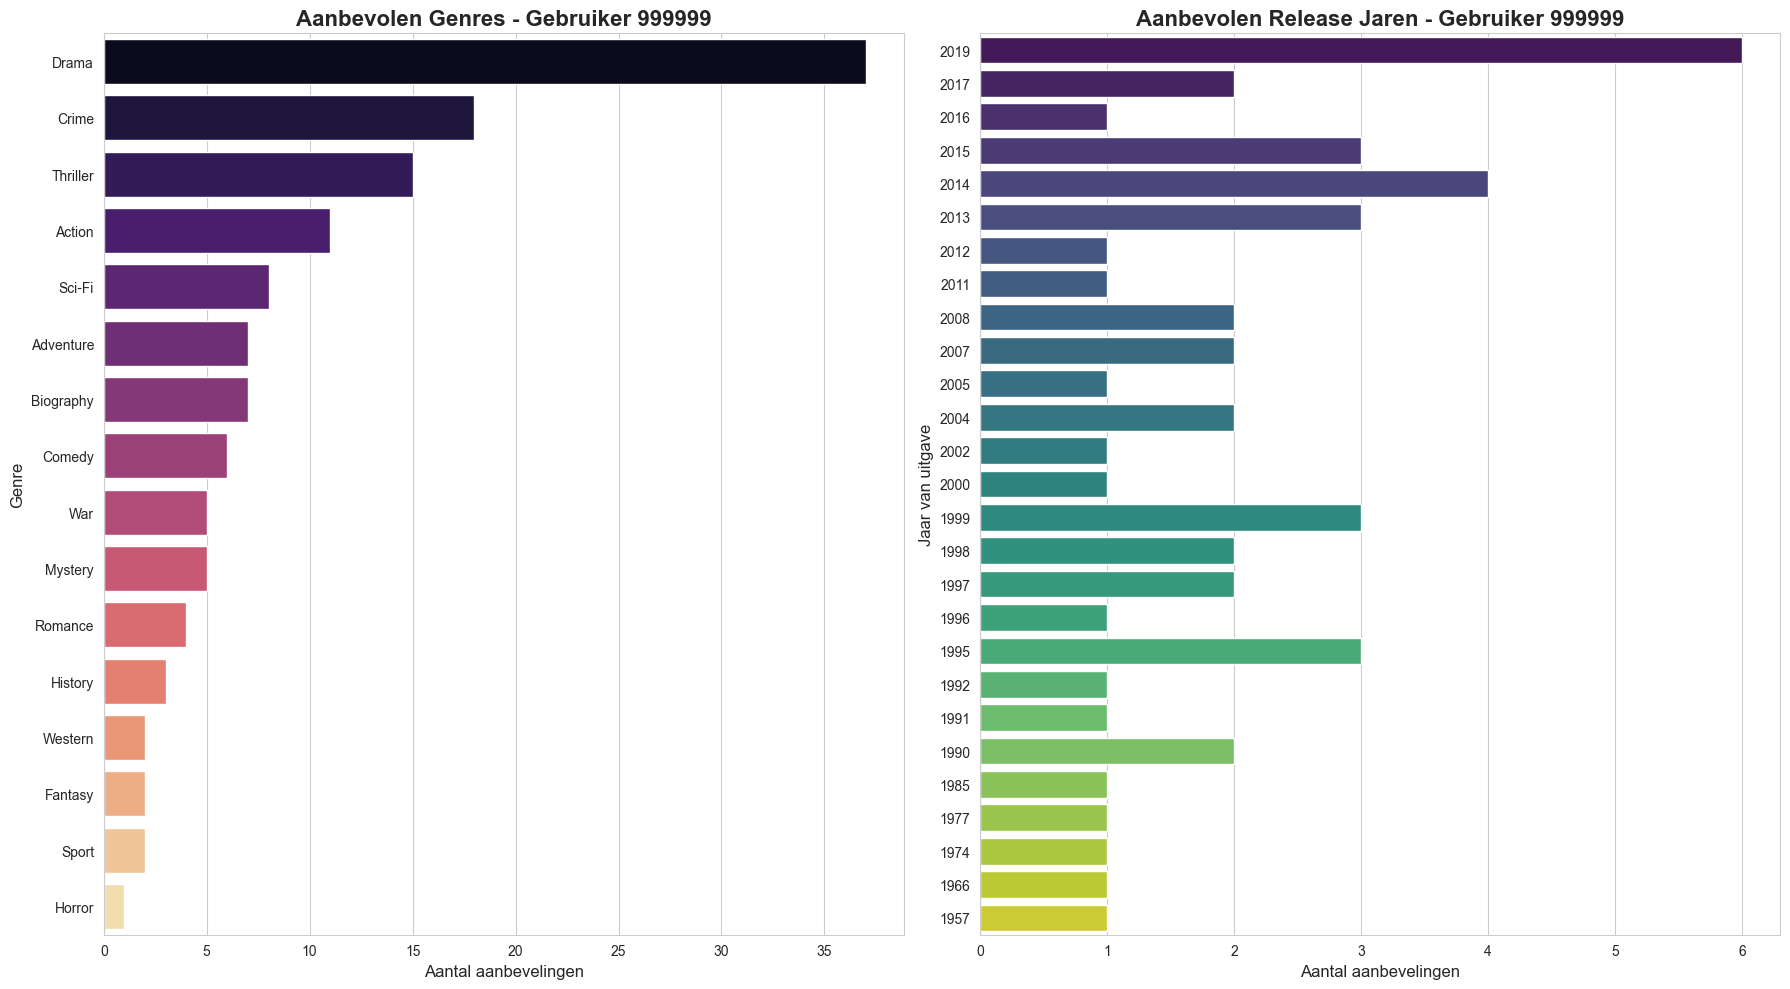

In [ ]:
# 8.4.9 Plotten van Jochems Aanbevelingsprofiel
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re

def plot_recommendation_profile(user_id, recommendations_list):
    # 1. Haal de aanbevolen films op uit movies.dat
    # Gebruik de MovieID en Title_with_Year kolommen uit jouw movies_dat
    movies_dat = pd.read_csv(
        "movies.dat",
        sep="::",
        engine="python",
        names=["MovieID", "Title_with_Year", "Genres_dat"]
    )
    rec_movies = movies_dat[movies_dat['MovieID'].isin(recommendations_list)].copy()

    if rec_movies.empty:
        print("Geen aanbevelingen gevonden in de dataset.")
        return

    # 2. Genres verwerken
    all_genres = []
    # In movies.dat zijn genres gescheiden door | (bv. Drama|Thriller)
    for g_str in rec_movies['Genres_dat']:
        all_genres.extend(g_str.split('|'))
    genre_counts = pd.Series(all_genres).value_counts()

    # 3. Jaren verwerken (Extractie uit Title_with_Year)
    def extract_year(title):
        match = re.search(r'\((\d{4})\)', str(title))
        return int(match.group(1)) if match else None

    rec_movies['Year'] = rec_movies['Title_with_Year'].apply(extract_year)
    # Sorteer jaren van nieuw naar oud voor de verticale as
    year_counts = rec_movies['Year'].value_counts().sort_index(ascending=False)

    # 4. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 10))
    sns.set_style("whitegrid")

    # Plot A: Aanbevolen Genres
    sns.barplot(x=genre_counts.values, y=genre_counts.index, ax=ax1, palette="magma", hue=genre_counts.index, legend=False)
    ax1.set_title(f'Aanbevolen Genres - Gebruiker {user_id}', fontsize=16, fontweight='bold')
    ax1.set_xlabel('Aantal aanbevelingen', fontsize=12)
    ax1.set_ylabel('Genre', fontsize=12)

    # Plot B: Aanbevolen Release Jaren
    sns.barplot(x=year_counts.values, y=year_counts.index.astype(str), ax=ax2, palette="viridis", hue=year_counts.index.astype(str), legend=False)
    ax2.set_title(f'Aanbevolen Release Jaren - Gebruiker {user_id}', fontsize=16, fontweight='bold')
    ax2.set_xlabel('Aantal aanbevelingen', fontsize=12)
    ax2.set_ylabel('Jaar van uitgave', fontsize=12)

    plt.tight_layout()
    plt.show()

# Gebruik de functie voor je vriend
recommendations_his = recommendations_final[FRIEND_USER_ID]
plot_recommendation_profile(FRIEND_USER_ID, recommendations_his)

Ik heb alle 50 aanbevelingen naar Jochem gestuurd en dit zijn de resultaten (*zie hieronder en output #8.4.8*). In beide aanbevelingen en historie heeft zie je in de top 3 jaren 2013, 2014 en 2019 terug. Ook in beide top 3s zie je Drama, Thriller en Crime (*zie output #8.4.9*). 

- ❌ (28) = Slechte recomendation
- ✅ (4) = Goede recomendation
- 🟦 (18) = Al gezien dus eigenlijk ook goed

1. ❌ Goodfellas (1990) Genres: Biography, Crime, Drama
2. 🟦 Batman Begins (2005) Genres: Action, Adventure 
3. ❌ The Godfather: Part II (1974) Genres: Crime, Drama
4. ❌ Gisaengchung (2019) Genres: Drama
5. 🟦 John Wick (2014) Genres: Action, Crime, Thriller
6. 🟦 Three Billboards Outside Ebbing, Missouri (2017) Genres: Crime, Drama
7. ❌ American Beauty (1999) Genres: Drama
8. 🟦 Hacksaw Ridge (2016) Genres: Biography, Drama, History, War
9. ❌ The Imitation Game (2014) Genres: Biography, Drama, Thriller, War
10. ❌ There Will Be Blood (2007) Genres: Drama
11. 🟦 Heat (1995) Genres: Crime, Drama, Thriller
12. 🟦 The Matrix (1999) Genres: Action, Sci-Fi
13. ❌ Braveheart (1995) Genres: Biography, Drama, History, War
14. 🟦 12 Angry Men (1957) Genres: Crime, Drama
15. ❌ Warrior (2011) Genres: Drama, Sport
16. ❌ Lone Survivor (2013) Genres: Action, Biography, Drama, War
17. 🟦 L.A. Confidential (1997) Genres: Crime, Drama, Mystery, Thriller
18. 🟦 Kingsman: The Secret Service (2014) Genres: Action, Adventure, Comedy, Thriller
19. 🟦 The Gentlemen (2019) Genres: Action, Crime
20. 🟦 The Irishman (2019) Genres: Biography, Crime, Drama, History, Thriller
21. ❌ Room (2015) Genres: Drama, Thriller
22. ✅ The Hateful Eight (2015) Genres: Crime, Drama, Mystery, Thriller, Western
23. ❌ The Hunger Games: Catching Fire (2013) Genres: Action, Adventure, Sci-Fi, Thriller
24. 🟦 Zodiac (2007) Genres: Crime, Drama, Mystery, Thriller
25. ❌ Argo (2012) Genres: Biography, Drama, Thriller
26. 🟦 The Sixth Sense (1999) Genres: Drama, Mystery, Thriller
27. ✅ The Curious Case of Benjamin Button (2008) Genres: Drama, Fantasy, Romance
28. ❌ It (2017) Genres: Horror, Thriller
29. ✅ Casino (1995) Genres: Crime, Drama
30. ❌ Titanic (1997) Genres: Drama, Romance
31. 🟦 The Truman Show (1998) Genres: Comedy, Drama, Sci-Fi
32. 🟦 The Big Lebowski (1998) Genres: Comedy, Crime
33. ❌ Il buono, il brutto, il cattivo (1966) Genres: Western
34. ❌ Scent of a Woman (1992) Genres: Drama
35. ❌ Gangs of New York (2002) Genres: Crime, Drama
36. ❌ Cast Away (2000) Genres: Adventure, Drama, Romance
37. ❌ Jojo Rabbit (2019) Genres: Comedy, Drama, War
38. ❌ Fargo (1996) Genres: Crime, Drama, Thriller
39. ❌ Eternal Sunshine of the Spotless Mind (2004) Genres: Drama, Romance, Sci-Fi
40. ❌ Gran Torino (2008) Genres: Drama
41. ❌ Back to the Future (1985) Genres: Adventure, Comedy, Sci-Fi
42. ❌ Dawn of the Planet of the Apes (2014) Genres: Action, Adventure, Drama, Sci-Fi
43. 🟦 Now You See Me (2013) Genres: Crime, Mystery, Thriller
44. ❌ Million Dollar Baby (2004) Genres: Drama, Sport
45. 🟦 Star Wars (1977) Genres: Action, Adventure, Fantasy, Sci-Fi
46. ❌ Terminator 2: Judgment Day (1991) Genres: Action, Sci-Fi
47. 🟦 El Camino: A Breaking Bad Movie (2019) Genres: Action, Drama
48. ❌ The Godfather: Part III (1990) Genres: Crime, Drama
49. ❌ Marriage Story (2019) Genres: Comedy, Drama
50. ✅ Spotlight (2015) Genres: Crime, Drama

22/50 films zijn goed, dus `22/50*100=44% precision`

het model heeft dus een precision van 44% behaald op de data van Jochem. Zoals ik had verwacht werkt het model beter op iemand andere omdat mijn filmsmaak dus een beetje raar is. Er zal vast ook veel bias in mijn eigen data zitten omdat ik alle films op het zelfde moment heb beoordeeld en omdat ik elke film erin heb geprobeerd te zetten die ik in heel mijn leven heb gezien, ook kinderjaren. En vast ook een hoop films heb gemist waardoor het niet perfect een beeld heeft van wat ik zelf heb gezien.

Stel dat ik en Jochem een "Test set" zouden zijn wat zeker kan in dit scenario, dan zou mijn model op de deze test set een score van `(44+38)/2=41% precision`. Maar, 
- een testset van 2 is wel aardig klein
- nu gebruiken we wel precision ipv modified precision omdat we geen users hebben waarbij de precision gegarandeerd 0, 0.33, of 0.66 is.
- we recomenden 50 films ipv 3. (doe ik omdat we dan toch iets meer resultaten hebben en het model tegelijk iets meer testen omdat ik niet veel users heb)

Maar al met al kan ik wel zeggen dat het model wel werkt en inderdaad films kan aanraden op basis van de films die je leuk vind door te kijken naar andere users hun kijk historie.

## 8.5 Voor- en Nadelen van dit Model

Het nadeel van dit model is dat je afhankelijk bent van de smaak van andere users. stel dat je een hele gekke filmsmaak hebt dat je bijvoorbeeld niet films leuk vind per genre, of per jaartal of een andere feature die makkelijk gevonden kan worden. Dan kan het best moeilijk zijn voor dit model om te achterhalen wat je leuk vind aangezien we de film historie van andere gebruikers gebruiken om voor jou films aan te raden.

Dit kan dus ook een voordeel zijn. Er zijn veel mensen die een bepaalde filmsmaak delen. Denk aan Mainstream films, horror films, animatie films, etcetera. met gebruik van matrix factorization kunnen we deze patronen dus opsporen en zo aanbevelingen maken. 

Ik wilde zeggen dat een nadeel van dit model is dat we niet direct kijken naar genres van films omdat we geen content based strategie gebruiken. Maar tot mijn verbazing werkte de matrix factorization zo goed dat op de "normale" users, toch telkens films werden aangeraden die paste binnen hun genres. Ik krijg ook enorm veel animatie films aangeraden, waarschijnlijk dus omdat ik die allemaal hoge cijfers heb gegeven.

een voordeel is dat we de gegeven beoordelingen meenemen in het proces. Bij mijn profiel blijkt dit een beetje een tegenvaller te zijn aangezien ik enorm veel animatiefilms krijg die ik niet wil zien. Maar dit laat dus zien dat de cijfers die je geeft ook daadwerkelijk impact hebben op het model.

een voordeel is dat het best snel runt. recomendaties genereren duurt zo een 20 seconde.

nadeel van het model is dat we niet kijken naar hoe laat of beter gezegd op welk dagdeel iemand een film kijkt. zo kan het misschien interessant zijn om dat bijtehouden omdat misschien horror films vaker snachts worden gekeken. als jij vaak snachts films kijkt misschien moet je een keer een horror film proberen?

## 8.6 Verbetersuggesties

Om dit model te verbeteren kun je verschillende dingen doen

1. film meta-data toevoegen vanuit movies.dat. ik had deze dataset wat aan de latere kant gevonden toen ik al veel verantwoording had geschreven dus wilde niet alles opnieuw doen. Maar door meta-data toe te voegen kun je dus een content based approach combineren met een collaborative filtering approach en zo een hybrid model maken. Dit lijkt mij een veelbelovend idee aangezien de winnaars van de netflix prijs ook deze approach hebben gebruikt

verbeterpunten buiten mijn model

1. een grote verbeter suggestie zou zijn om op een of andere manier real-time feedback van users terug te krijgen. Dit kan natuurlijk niet omdat we statische data hebben, maar wat hebben we dat aan de recomendations? Ik snap dat de val set later in tijd gebeurt, maar misschien geef ik wel 3 hele goede recomendations die de user nog niet gezien heeft in de valset? Daar krijg je dan geen antwoord op. Misschien had mijn model wel een modified precision van 70% gehaald als er live feedback was maar dat is er dus niet. Ik heb geprobeerd om zelf "live user feedback" te creeeren door mijn eigen film historie op een rijtje te zetten en die van Jochem op te vragen. En het blijkt dat het model in de praktijk veel beter werkt dan op de trainset/valset (al is dit een zwakke claim aangezien we maar 2 users hebben getest (ik en jochem) maar beide users hadden wel een duidelijk hogere score dan tijdens het trainen)

2. Een goeie verbeter suggestie zou zijn om iedereen die minder dan x reviews heeft achtergelaten, te verwijderen uit de datatset. Dit voorkomt zoveel gedoe waardoor je gewoon normaal precision zou kunnen gebruiken. maar inde opdracht staat dat dit niet mag.

# 9. Conclusie
Ja ik heb in de validatieset gekeken om een metriek op te stellen voor de gegeven scenario. Zo heb ik een idee gekregen of dat mijn model beter was dan mijn baseline model. In retrospect, Was dit perse nodig om erachter te komen of dat mijn model beter was dan mijn baseline model? Nee, dat hoefde in princiepe niet. Ik kon ook naar de normale precision kijken om te begrijpen of dat mijn model daadwerkelijk beter presteert. Kijken we in de tabel hieronder zien we dat de normale precision ook al hoger is, dus we hoefden in princiepe niet in de valset te kijken en deze nieuwe metriek op te stellen. Heeft het dan enige voordeel gehad om in de valset te kijken? Jazeker, want door te kijken in de valset weet ik wat de theoretische maximale score is die we kunnen behalen op de valset. Zo kunnen we voor precision de score 1.0/100% nastreven net als normale machine learning problemen. Dus ik ben er tot nu aan nog steeds van overtuigd dat het een meerwaarde heeft gehad om te kijken in de valset. Het nadeel is wel dan weer dat het alleen werkt voor deze valset. Mocht je willen weten hoe goed de precision is relatief tot de testset, dan moet je ook weer gaan kijken in de testset. 

Het was dus zeker niet nodig om in de valset te kijken om te begrijpen of het model beter presteert, wel om te kijken hoe goed het model presteert. Zou ik dit de volgende keer weer doen? Op de valset ja, want dan kunnen we dus streven naar 100% precision en het model steeds verbeteren. Op de testset? Nee, want de testset is puur om te kijken hoe goed het model presteert op data die het model nooit gezien heeft. Je kunt dan altijd nog de normale precision gebruiken en vergelijken met de valset om te kijken hoe goed het werkt op de testset zonder te modified precision te gebruiken.

| Model | Hits | Precision | Modified Precision |
|-------|------|-----------|--------------------|
| THEORATICAL MAX VAL SET | 4222 | 0.019627 | 100% |
| Baseline Model | 362 | 0.001683 | 8.58% |
| CF + MF Model | 396 | 0.001841 | 9.38% |

Ik heb uiteindelijk niet gekeken in mijn test split en ook niet de 2de test set met live user feedback. Zo heb ik toch op een manier data leakage soort van voorkomen. Ik ben ervan overtuigd dat het pas data leakage is als je kijkt in de valset/testset en op basis van die informatie design keuzes gaat maken. Heb ik op basis van informatie in de valset/testset design keuzes gemaakt? op de valset ja, op de test set nee. ben beniewd hoe het zal scoren.

# 10. Nawoord
Achteraf dacht ik of het misschien toch een idee was om iedereen gewoon voor elke film een 5 te laten geven om de missing data op te vullen. Dan kon ik ook de ratings gaan predicten en een andere metriek gebruiken buiten de classificatie metrieken. Maar dan ga je dus data invullen voor de users. Dus in mijn optiek is er geen enkele methode dat 100% overal rekening meehoud. Misschien was dat interessant geweest voor een andere iteratie om te kijken hoe goed dat scoorde.

Sorry dat het document zo lang is geworden dat hoefde denk ik niet. Ik heb nog nooit zoveel moeten filosoferen binnen een opdracht. Waarschijnlijk dus ook omdat er niet een duidelijk beste antwoord/manier is maar meerdere goede antwoorden/manieren.